In [1]:
# Cell 1: Setup
"""
# ArcticDEM Transect Elevation Profile Analysis
Extract and compare elevation profiles across multiple DEMs along a transect.
"""

import sys
sys.path.append('..')

import importlib
from config import OUTPUT_DIR, ARCHIVE_DIR
import analysis
import elevation_utils
importlib.reload(analysis)
importlib.reload(elevation_utils)  # Reload modules to reflect any changes
from analysis import run_transect_analysis, plot_combined_profiles, additional_plots, filter_outlier_profiles, process_elevation_profiles
from elevation_utils import generate_orthogonal_transects, read_transects_from_geoparquet, search_arcticdem_strips, filter_strip_dems, get_dem_metadata, get_strip_ids

import time
from ipyleaflet import (
    AwesomeIcon,
    FullScreenControl,
    GeoJSON,
    Polyline,
    Map,
    Marker,
    basemaps,
)
from IPython.display import clear_output, display
from ipywidgets import HTML, Button, HBox, Layout, VBox, widgets  # type: ignore
from pyproj import Transformer  # type: ignore
from rasterio import warp
from rasterio.features import shapes
from shapely.geometry import mapping, shape
from geopy.distance import geodesic as geopydistance  # type: ignore

########################################################################
def stac_api_transect(raster_data=None, raster_metadata=None, mask=None, timeout=2):
    """
    Function to use an interactive map allowing the user to select a transect using draggable markers.
    If a raster is provided, it will display its footprint.

    Parameters:
    -----------
    raster_data : ndarray, optional
        2D array of raster values (default: None)
    raster_metadata : dict, optional
        Metadata dictionary containing raster bounds, src and transform (default: None)
    mask : ndarray, optional
        Mask for the raster data (1 for valid, 0 for invalid) (default: None)
    timeout : int, optional
        Timeout in seconds for user interaction (default: 20)

    """
    global coords
    coords = (-54.2, 75, -54.3, 75.05)
    center_lon = -54.25
    center_lat = 75.025
    mid_lat = center_lat
    start_lon = coords[0] + (coords[2] - coords[0]) / 3
    end_lon = coords[0] + 2 * (coords[2] - coords[0]) / 3
    # Create a leaflet map widget to find an AOI for the spatial query of the STAC API
    m = Map(
        basemap=basemaps.Esri.WorldImagery,
        scroll_wheel_zoom=True,
        center=(center_lat, center_lon),
        zoom=6,
        layout=Layout(height="380px", width="700px"),
    )

    if raster_data is not None:
        # Transform raster bounds to WGS84 (EPSG:3857) for the map
        print(f"Raster shape: {raster_data.shape}")
        transform = raster_metadata["transform"]
        bounds = raster_metadata["bounds"]
        crs_src = raster_metadata["crs"]

        # Transform bounds to WGS84 (EPSG:4326) for the map # I thought it was EPSG:3857
        transformer = Transformer.from_crs(crs_src, "EPSG:4326", always_xy=True)
        lons, lats = transformer.transform(
            [bounds.left, bounds.right], [bounds.bottom, bounds.top]
        )
        west, east = lons
        south, north = lats

        bounds_wgs84 = (west, south, east, north)
        print(f"Raster bounds in WGS84: {bounds_wgs84}")

        # Calculate center of bounds
        center_lon = (bounds_wgs84[0] + bounds_wgs84[2]) / 2
        center_lat = (bounds_wgs84[1] + bounds_wgs84[3]) / 2

        # Extract shapes (this is the expensive step!)
        shapes_gen = shapes(mask, transform=transform)
        polygons = [shape(geom) for geom, val in shapes_gen if val == 1]

        if not polygons:
            raise ("Warning: No valid polygons found.")

        for i, poly in enumerate(polygons):
            # Transform polygon to WGS84
            wgs84_poly = warp.transform_geom(crs_src, "EPSG:4326", mapping(poly))
            geojson_poly = GeoJSON(
                data=wgs84_poly,
                style={
                    "color": "lime",
                    "fillColor": "lime",
                    "opacity": 0.8,
                    "fillOpacity": 0.2,
                    "weight": 2,
                },
                name=f"Raster Boundary {i+1}",
            )
            m.add_layer(geojson_poly)

        # Add markers at 1/3 and 2/3 of the raster's width
        start_lon = bounds_wgs84[0] + (bounds_wgs84[2] - bounds_wgs84[0]) / 3
        end_lon = bounds_wgs84[0] + 2 * (bounds_wgs84[2] - bounds_wgs84[0]) / 3
        mid_lat = (bounds_wgs84[1] + bounds_wgs84[3]) / 2

    m.add_control(FullScreenControl())
    result_output = widgets.Output()

    # Create info display
    info_html = HTML(
        value="<b>Drag the marker, then click Confirm</b>",
        layout=Layout(padding="10px"),
    )

    # Create confirmation button
    confirm_button = Button(
        description="Confirm Selected Points",
        button_style="success",
        disabled=False,
        tooltip="Click after placing marker",
    )

    # Create markers (initially slightly offset from center)
    start_marker = Marker(
        # location=(center_y, center_x - 0.1),
        location=(mid_lat, start_lon),  # Leaflet expects (lat, lon)
        draggable=True,
        name="Start (A)",
        icon=AwesomeIcon(name="play", marker_color="red"),
    )

    end_marker = Marker(
        # location=(center_y, center_x + 0.1),
        location=(mid_lat, end_lon),  # Leaflet expects (lat, lon)
        draggable=True,
        name="End (B)",
        icon=AwesomeIcon(name="stop", marker_color="blue"),
    )

    m.add_layer(start_marker)
    m.add_layer(end_marker)

    # Add line between markers
    line = Polyline(
        locations=[(mid_lat, start_lon), (mid_lat, end_lon)], color="purple", weight=3
    )
    m.add_layer(line)

    # Update line when markers move
    def update_line(*args):
        line.locations = [
            (start_marker.location[0], start_marker.location[1]),
            (end_marker.location[0], end_marker.location[1]),
        ]

    start_marker.observe(update_line, names=["location"])
    end_marker.observe(update_line, names=["location"])

    def update_display(*args):
        # Remember: Leaflet uses (lat, lon) format, but we want to store as (lon, lat)
        start_lat, start_lon = start_marker.location[0], start_marker.location[1]
        end_lat, end_lon = end_marker.location[0], end_marker.location[1]
        # Calculate distance between points
        dist = geopydistance((start_lat, start_lon), (end_lat, end_lon)).kilometers

        info_html.value = (
            f"<b>Current Positions:</b><br>"
            f"<span style='color:red'>Start (A):</span> Lon: {start_lon:.3f}, Lat: {start_lat:.3f}<br>"
            f"<span style='color:blue'>End (B):</span> Lon: {end_lon:.3f}, Lat: {end_lat:.3f}<br>"
            f"<span style='color:purple'>Distance:</span> {dist:.2f} km"
        )

    def on_confirm(b):
        global coords
        # Store as (lon, lat) for consistency with GIS conventions
        start_coords = (start_marker.location[1], start_marker.location[0])
        end_coords = (end_marker.location[1], end_marker.location[0])
        with result_output:
            result_output.clear_output()
            print(
                f"Points confirmed!\n\
                    Start (lon, lat): {start_coords[0]:.3f}, {start_coords[1]:.3f}\n\
                    End (lon, lat): {end_coords[0]:.3f}, {end_coords[1]:.3f}"
            )
            # Store results in global variable
            global coords
            coords = (start_coords, end_coords)

    confirm_button.on_click(on_confirm)
    start_marker.observe(update_display, names=["location"])
    end_marker.observe(update_display, names=["location"])
    update_display()  # Initial display update

    # Display all components
    display(VBox([info_html, m, HBox([confirm_button]), result_output]))

    # Wait for confirmation with timeout
    start_time = time.time()
    while (time.time() - start_time) < timeout:
        time.sleep(0.1)

    # No clear_output here: it would wipe the map as soon as the calling
    # cell prints anything else, before Confirm can be clicked
    return coords

print("✓ Modules loaded")


Elevation from DEMs Configuration
✓ ARCHIVE_DIR: /home/moralpom/luna/CPOM/archive/SATS/OPTICAL/ArcticDEM/strips/s2s041/2m/
✓ MOSAIC_DIR: /home/moralpom/luna/CPOM/archive/SATS/OPTICAL/ArcticDEM/mosaic/v4.1/2m/
✓ MOSAIC_INDEX_DIR: /home/moralpom/luna/CPOM/archive/SATS/OPTICAL/ArcticDEM/ArcticDEM_Mosaic_Index_latest_shp/
✓ OUTPUT_DIR: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/

✓ Modules loaded


In [2]:
# Cell 2: Configure Parameters
"""
## Configuration
"""

# Analysis parameters
TIME_RANGE = "2011-01-01/2026-12-31"
MAX_DEMS = 180                          # Maximum number of DEMs to process
COREG_MODE = 'altim'                    # 'none', 'altim', or 'mosaic'
if COREG_MODE == 'none':
    MAX_DEMS = 18                          # Maximum number of DEMs to process
LAKE_NAME = None                       # Optional name for plots (e.g., "Lake X")
REF_YEAR = None                        # Optional reference year for relative difference plots (e.g., 2015)
MAX_CLOUD_COVER = 0.99                  # Maximum cloud cover fraction for filtering DEMs
# 

# Coordinate selection
INPUT_METHOD =  1  # <-- CHANGE THIS: 1=Interactive, 2=Manual, 3=Auto-orthogonal, 4=GeoParquet

print(f"Input method: {INPUT_METHOD}")
print(f"  1 = Interactive map")
print(f"  2 = Manual coordinate entry")
print(f"  3 = Auto-generate from center point")
print(f"  4 = Batch from GeoParquet file")

print(f"Archive: {ARCHIVE_DIR}")
print(f"Time range: {TIME_RANGE}")
print(f"Max DEMs: {MAX_DEMS}")
print(f"Coregistration: {COREG_MODE}")
print(f"Lake name: {LAKE_NAME}")
print(f"Max cloud cover: {MAX_CLOUD_COVER}")

Input method: 1
  1 = Interactive map
  2 = Manual coordinate entry
  3 = Auto-generate from center point
  4 = Batch from GeoParquet file
Archive: /home/moralpom/luna/CPOM/archive/SATS/OPTICAL/ArcticDEM/strips/s2s041/2m/
Time range: 2011-01-01/2026-12-31
Max DEMs: 180
Coregistration: altim
Lake name: None
Max cloud cover: 0.99


In [ ]:
# Cell 3: Select Transect
"""
## Define Transect
Select start and end points for the elevation profile.
"""
# ============================================================================
# METHOD 1: Interactive Map
# ============================================================================
if INPUT_METHOD == 1:
    print("\nUse the map to define your transect...")
    print("Drag the RED marker (start) and BLUE marker (end), click Confirm, then run the next cell")
    # The Confirm button updates `coords` after this cell has finished, so the
    # transect list is built at the start of the next cell. Nothing may be
    # printed after the map in this cell.
    transect_list = []
    stac_api_transect(
        timeout=2
    )

# ============================================================================
# METHOD 2: Manual Coordinates
# ============================================================================
elif INPUT_METHOD == 2:
    coord_input = input(
        "Enter coordinates as lon1,lat1,lon2,lat2 "
        "(e.g. -54.2,75.0,-54.3,75.05): "
    )
    parts = list(map(float, coord_input.replace('_', ',').replace(' ', ',').split(',')))
    transect_coords = ((parts[0], parts[1]), (parts[2], parts[3]))
    
    transect_list = [(transect_coords, "User-defined", None)]
    print(f"\n✓ Start: ({transect_coords[0][0]:.3f}°E, {transect_coords[0][1]:.3f}°N)")
    print(f"✓ End:   ({transect_coords[1][0]:.3f}°E, {transect_coords[1][1]:.3f}°N)")

# ============================================================================
# METHOD 3: Auto-generate from Center Point
# ============================================================================
elif INPUT_METHOD == 3:
    # Provide center coordinates
    center_input = input(
        "Enter center coordinates as lon,lat (e.g. -48.30,63.85): "
    )
    
    # Use predefined center if empty input
    if not center_input.strip():
        center_input = "-48.30,63.85"  # <-- SET YOUR DEFAULT CENTER HERE
        print(f"Using default center: {center_input}")
    
    center_coords = tuple(map(float, center_input.replace('_', ',').replace(' ', ',').split(',')[:2]))
    
    # Half-length of transects (3km each way = 6km total)
    half_length = 3000  # meters
    
    transect_list = generate_orthogonal_transects(center_coords, half_length_m=half_length)
    
    print(f"\n✓ Center point: ({center_coords[0]:.4f}°E, {center_coords[1]:.4f}°N)")
    for transect_coords, direction in transect_list:
        start, end = transect_coords
        print(f"  {direction}:")
        print(f"    Start: ({start[0]:.4f}°E, {start[1]:.4f}°N)")
        print(f"    End:   ({end[0]:.4f}°E, {end[1]:.4f}°N)")

# ============================================================================
# METHOD 4: Batch from GeoParquet
# ============================================================================
elif INPUT_METHOD == 4:
    # Path to GeoParquet file
    parquet_path = input(
        "Enter path to GeoParquet file: "
    ).strip()
    
    # Use default if empty
    if not parquet_path:
        parquet_path = "/home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/selected_candidates_28july2026.gpkg"
        # parquet_path = "/home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/sample_diego_sites_for_notebook.gpkg"  # <-- SET DEFAULT
        print(f"Using default file: {parquet_path}")
    
    # Column names (adjust if needed)
    label_column = input("Column for labels (Enter for 'Name'): ").strip()
    if not label_column:
        label_column = 'Name'
    
    half_length = 3000  # meters
    
    transect_list = read_transects_from_geoparquet(
        parquet_path,
        lat_col='lat',
        lon_col='lon',
        label_col=label_column,
        half_length_m=half_length
    )
    
    print(f"\n✓ Read {len(transect_list)} transects from file")

# ============================================================================
# Display all transects
# ============================================================================
if INPUT_METHOD != 1:  # interactive: the list is built in the next cell
    print(f"\n{'='*60}")
    print(f"TRANSECTS TO PROCESS: {len(transect_list)}")
    print(f"{'='*60}")
    for i, item in enumerate(transect_list):
        if len(item) == 3:
            transect_coords, label, direction = item
            start, end = transect_coords
            if direction:
                print(f"  {i+1}. [{label}] {direction}")
            else:
                print(f"  {i+1}. [{label}]")
        else:
            transect_coords, label = item
            start, end = transect_coords
            print(f"  {i+1}. [{label}]")
        print(f"      Start: ({start[0]:.4f}°E, {start[1]:.4f}°N)")
        print(f"      End:   ({end[0]:.4f}°E, {end[1]:.4f}°N)")


Use the map to define your transect...
Drag the RED marker (start) and BLUE marker (end), click Confirm, then run the next cell


In [4]:
# Cell 4: Process All Transects
"""
## Process Elevation Profiles
Loop through all transects and extract profiles.
"""

# Interactive map: read the coordinates confirmed on the map
if INPUT_METHOD == 1:
    if len(coords) == 4:  # Confirm not clicked: map placeholder (lon0, lat0, lon1, lat1)
        coords = ((coords[0], coords[1]), (coords[2], coords[3]))
    transect_list = [(coords, "User-defined", None)]
    print(f"✓ Start: ({coords[0][0]:.3f}°E, {coords[0][1]:.3f}°N)")
    print(f"✓ End:   ({coords[1][0]:.3f}°E, {coords[1][1]:.3f}°N)")

# Store results for all transects
all_transect_results = []

for i, item in enumerate(transect_list):
    # Unpack the transect info
    if len(item) == 3:
        transect_coords, label, direction = item
        if direction:
            lake_name = f"{label}_{direction.replace(' ', '')}"
        else:
            lake_name = label
    else:
        transect_coords, label = item
        lake_name = label
    
    start, end = transect_coords
    print(f"\n{'='*60}")
    print(f"PROCESSING TRANSECT {i+1}/{len(transect_list)}: {lake_name}")
    print(f"{'='*60}")
    
    # STAC search for this transect
    west = min(start[0], end[0]) - 0.001
    south = min(start[1], end[1]) - 0.001
    east = max(start[0], end[0]) + 0.001
    north = max(start[1], end[1]) + 0.001
    bbox = (west, south, east, north)
    
    items_gdf, items = search_arcticdem_strips(bbox, TIME_RANGE)
    items_gdf = filter_strip_dems(items_gdf, max_cloud_cover=0.2, max_items=MAX_DEMS)
    pairnames, geocells, dates = get_dem_metadata(items_gdf)
    
    print(f"Found {len(pairnames)} DEMs for this transect")
    
    # Process profiles
    all_profiles = process_elevation_profiles(
        transect_coords, pairnames, geocells, ARCHIVE_DIR,
        coreg_mode=COREG_MODE, time_range=TIME_RANGE,
        strip_ids=get_strip_ids(items_gdf)  # pins the strip segment
    )
    
    # Store results
    all_transect_results.append({
        'transect_coords': transect_coords,
        'lake_name': lake_name,
        'profiles': all_profiles,
        'n_profiles': len(all_profiles['profiles']),
    })
    
    print(f"✓ Processed {len(all_profiles['profiles'])} profiles for {lake_name}")

print(f"\n{'='*60}")
print(f"ALL TRANSECTS PROCESSED: {len(all_transect_results)}")
print(f"{'='*60}")


✓ Start: (-55.020°E, 75.607°N)
✓ End:   (-55.503°E, 75.530°N)

PROCESSING TRANSECT 1/1: User-defined
Found 95 StripDEMs
After cloud filter (<20%): 84 DEMs
After xtrack filter: 69 DEMs
Found 69 DEMs for this transect
Finding mosaic file for coordinates ((-55.01953125000001, 75.60680105154307), (-55.50292968750001, 75.53013598609307))
✓ Both points are in the same mosaic tile: 25_38_2_1
Using mosaic file: /home/moralpom/luna/CPOM/archive/SATS/OPTICAL/ArcticDEM/mosaic/v4.1/2m/25_38/25_38_2_1_2m_v4.1_dem.tif
Elevation range: 1479.7 to 1671.1 meters
Mosaic profile extracted successfully.

Processing 69 DEMs for elevation profiles...


  4%|▍         | 3/69 [00:00<00:03, 21.80it/s]

No altim file found for SETSM_s2s041_WV01_20240721_10200100F2A18F00_10200100F43CA300_2m_seg1
No altim file found for SETSM_s2s041_WV03_20240708_104001009738F900_1040010097D0E200_2m_seg1
No altim file found for SETSM_s2s041_WV02_20240706_10300100FD5F2700_10300100FE80F400_2m_seg1
No altim file found for SETSM_s2s041_WV03_20220804_104001007917A000_104001007A1DDD00_2m_lsf_seg1
No altim file found for SETSM_s2s041_WV02_20220802_10300100D7733600_10300100D7786C00_2m_lsf_seg1
No altim file found for SETSM_s2s041_WV01_20220730_10200100C92B4D00_10200100C93C6D00_2m_lsf_seg1
No altim file found for SETSM_s2s041_WV01_20220717_10200100C759CF00_10200100C8DC1E00_2m_lsf_seg1
No altim file found for SETSM_s2s041_WV02_20220512_10300100D2028500_10300100D25EBF00_2m_lsf_seg13
No altim file found for SETSM_s2s041_WV02_20220512_10300100D2028500_10300100D25EBF00_2m_lsf_seg12
No altim file found for SETSM_s2s041_WV02_20220512_10300100D2028500_10300100D25EBF00_2m_lsf_seg14
No altim file found for SETSM_s2s041_WV

100%|██████████| 69/69 [00:00<00:00, 84.37it/s] 

No altim file found for SETSM_s2s041_WV01_20120305_102001001A237600_102001001895CB00_2m_lsf_seg1
Successfully processed 2 profiles
✓ Processed 2 profiles for User-defined

ALL TRANSECTS PROCESSED: 1


In [5]:
# Cell 5: Filter Outlier Profiles
"""
## Filter Outlier Profiles
Diagnose elevation ranges and remove DEMs with unrealistic values before plotting.
This eliminates bad stripDEMs that would skew the analysis.

Works with both single transects and batch transect results.
"""
import numpy as np
from analysis import filter_outlier_profiles # , suggest_elevation_bounds

# Determine if we're working with single or batch results
if 'all_transect_results' in locals() and isinstance(all_transect_results, list):
    # Batch mode: all_transect_results is a list of dicts
    batch_mode = True
    transect_list = all_transect_results
    print(f"Batch mode: {len(transect_list)} transects to filter\n")
else:
    # Single mode: use all_profiles or profiles directly
    batch_mode = False
    transect_list = [{'lake_name': LAKE_NAME if 'LAKE_NAME' in locals() else 'Transect',
                      'profiles': all_profiles if 'all_profiles' in locals() else profiles}]
    print("Single transect mode\n")

# Process each transect
filtered_results = []

for i, transect_data in enumerate(transect_list):
    lake_name = transect_data.get('lake_name', f'Transect_{i+1}')
    profiles_data = transect_data.get('profiles', transect_data)  # Handle both formats
    
    if not profiles_data.get('profiles'):
        print(f"  ⚠️ {lake_name}: No profiles to filter - skipping")
        filtered_results.append(transect_data)
        continue
    
    n_profiles = len(profiles_data['profiles'])
    
    print(f"\n{'='*95}")
    print(f"FILTERING: {lake_name} ({n_profiles} profiles)")
    print(f"{'='*95}")
    
    # Show diagnostic table for this transect
    print(f"{'#':>3} {'DEM Name':<50} {'Min':>8} {'Max':>8} {'Mean':>8} {'Std':>8} {'Valid%':>8}")
    print("-" * 95)
    
    for j, profile in enumerate(profiles_data['profiles']):
        name = profile['metadata']['dem_name']
        elevations = np.array(profile['profile_values'])
        valid = elevations[~np.isnan(elevations)]
        
        if len(valid) > 0:
            valid_pct = 100 * len(valid) / len(elevations)
            flags = []
            if np.min(valid) < -500: flags.append("LOW")
            if np.max(valid) > 4000: flags.append("HIGH")
            if np.std(valid) > 500: flags.append("VAR")
            if valid_pct < 50: flags.append("SPARSE")
            flag_str = " ⚠️ " + ",".join(flags) if flags else ""
            
            print(f"{j:>3} {name:<50} {np.min(valid):>8.0f} {np.max(valid):>8.0f} "
                  f"{np.mean(valid):>8.0f} {np.std(valid):>8.0f} {valid_pct:>7.1f}%{flag_str}")
        else:
            print(f"{j:>3} {name:<50} {'N/A':>8} {'N/A':>8} {'N/A':>8} {'N/A':>8} {'0.0%':>8} ❌ NO DATA")
    
    # Apply filtering
    filtered = filter_outlier_profiles(profiles_data, verbose=True)
    
    # Update the transect data with filtered profiles
    transect_data['profiles_filtered'] = filtered
    transect_data['n_original'] = n_profiles
    transect_data['n_filtered'] = len(filtered['profiles'])
    transect_data['n_removed'] = n_profiles - len(filtered['profiles'])
    
    filtered_results.append(transect_data)
    
    print(f"\n  {lake_name}: {transect_data['n_filtered']}/{transect_data['n_original']} "
          f"profiles retained ({transect_data['n_removed']} removed)")

# Update the main variable
if batch_mode:
    all_transect_results = filtered_results
    print(f"\n{'='*95}")
    print(f"BATCH FILTERING COMPLETE")
    print(f"{'='*95}")
    total_original = sum(t.get('n_original', 0) for t in filtered_results)
    total_filtered = sum(t.get('n_filtered', 0) for t in filtered_results)
    total_removed = sum(t.get('n_removed', 0) for t in filtered_results)
    print(f"Total profiles: {total_original} → {total_filtered} retained ({total_removed} removed)")
else:
    all_profiles = filtered_results[0].get('profiles_filtered', filtered_results[0].get('profiles'))
    profiles = all_profiles
    print(f"\n✓ Using {len(profiles['profiles'])} profiles for plotting and analysis.")

Batch mode: 2 transects to filter


FILTERING: North-South (18 profiles)
  # DEM Name                                                Min      Max     Mean      Std   Valid%
-----------------------------------------------------------------------------------------------
  0 SETSM_WV02_20241030_10300101072C6700_1030010107D25700       30      307       96       73    76.8%
  1 SETSM_WV03_20231124_104001008C520A00_104001008CCF2E00       32      306       93       73    76.6%
  2 SETSM_WV02_20221123_10300100DD462B00_10300100DDC7E400       33      313      108       79    81.4%
  3 SETSM_WV01_20220907_10200100CB9F2000_10200100CC950400       23      359      156      105    84.8%
  4 SETSM_WV01_20210528_10200100B103A200_10200100B1176600       59      356      191       94    64.4%
  5 SETSM_WV02_20201111_10300100B0A15C00_10300100B168A600       22      355      144      105    93.2%
  6 SETSM_WV01_20200331_1020010093450600_10200100966EFE00       37      357      189       95    66.0%
  7 SETSM_

Batch mode: generating plots for 2 transects


PLOTTING: North-South (16 profiles)

  Generating combined profile plot...
Median elevation: 93.4 ± 98.9 m
Y-axis limits: -26.53 to 393.51
Range: 350.03, Padding: 35.00
Combined profile plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/transects_combined/profile_North-South_-48.003_61.026_-47.997_60.974-2011-2026_none.png
  ✓ Combined plot saved: profile_North-South_-48.003_61.026_-47.997_60.974-2011-2026_none.png
  Generating relative differences plot...
dem_name: SETSM_WV01_20110920_10200100160A8900_1020010014DDC800
Plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/transects_combined/profile_diff_North-South_-48.003_61.026_-47.997_60.974-2011-2026_none.png


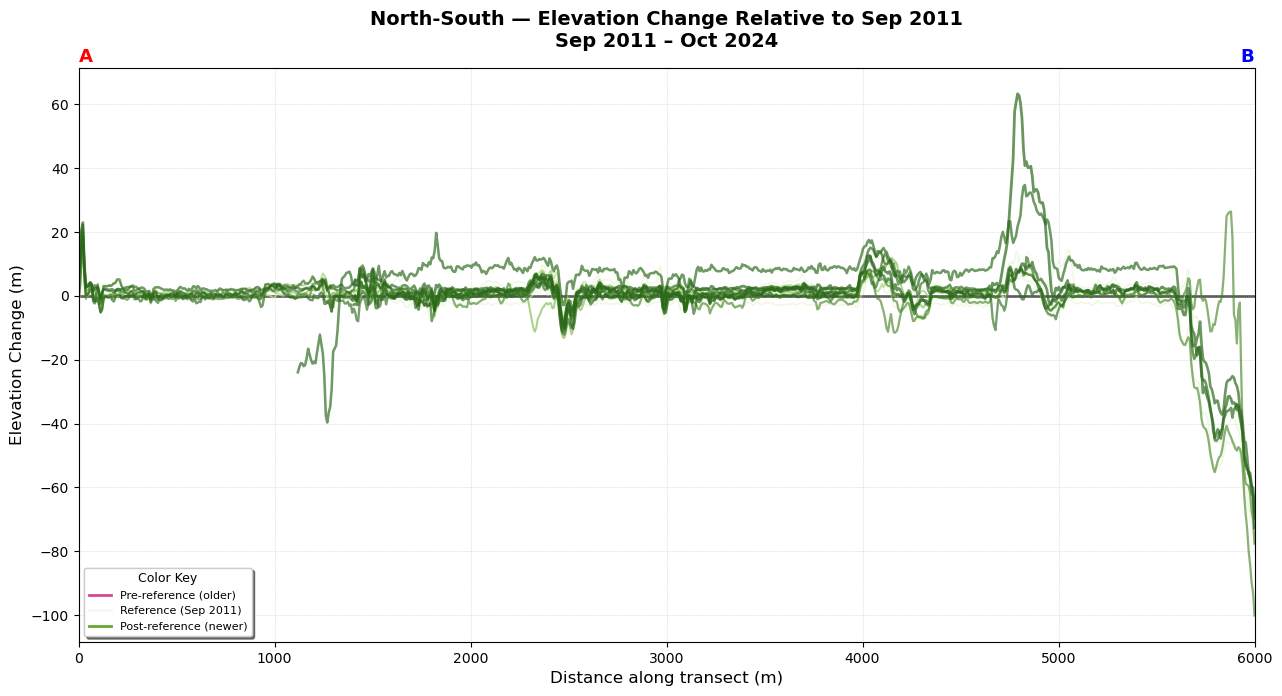

  ✗ Error in difference plot: expected str, bytes or os.PathLike object, not Figure
  Generating difference heatmap...
Heatmap saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/transects_combined/heatmap_North-South_-48.003_61.026_-47.997_60.974-2011-2026_None.png


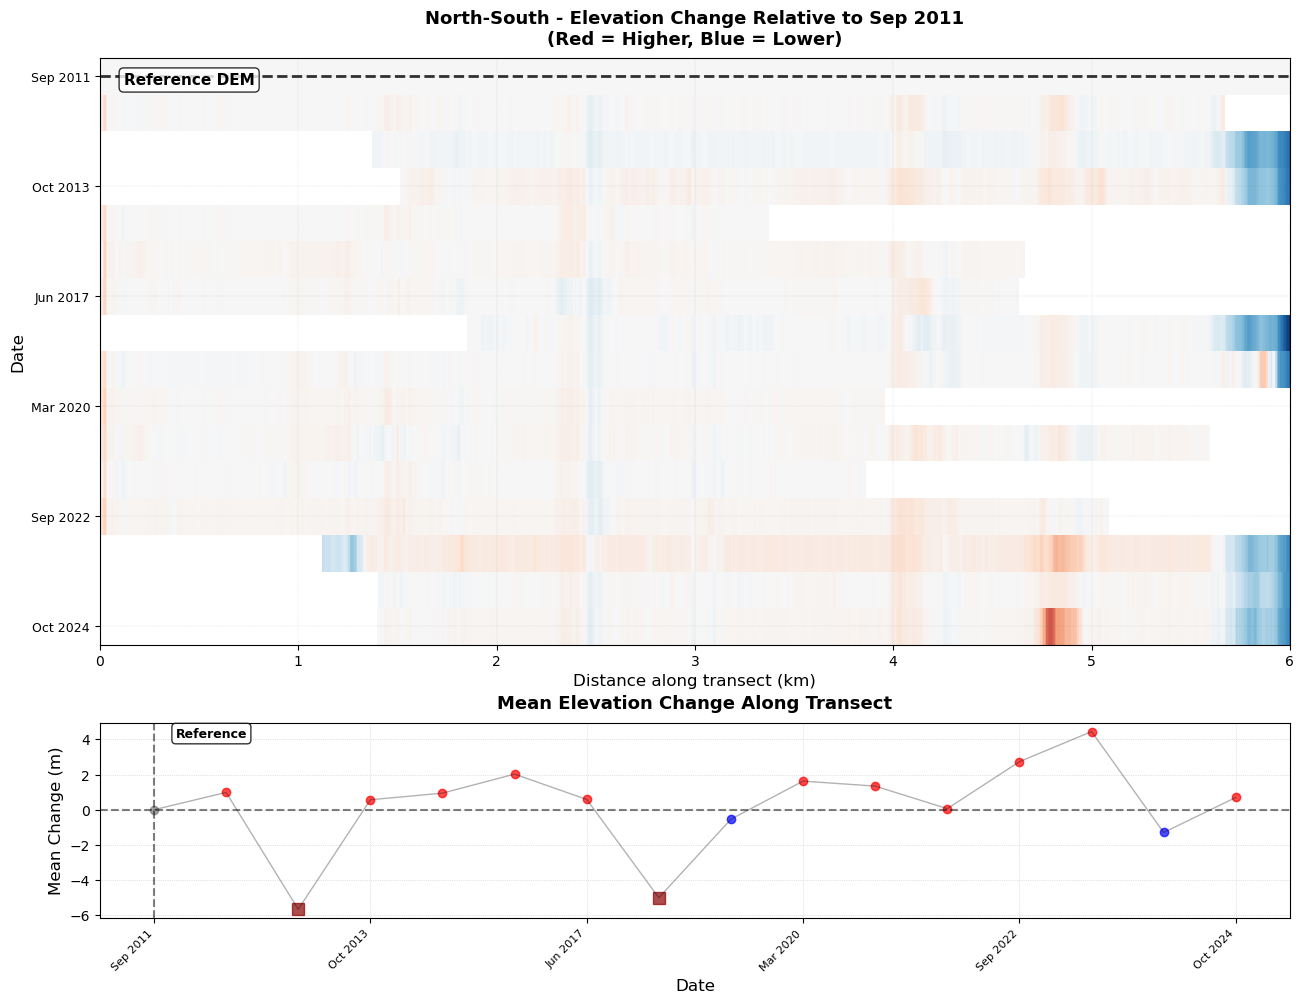

  ✓ Heatmap saved: heatmap_North-South_-48.003_61.026_-47.997_60.974-2011-2026_None.png
  ✓ All plots generated for North-South

PLOTTING: East-West (13 profiles)

  Generating combined profile plot...
Median elevation: 133.2 ± 72.4 m
Y-axis limits: 13.97 to 319.02
Range: 254.21, Padding: 25.42
Combined profile plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/transects_combined/profile_East-West_-48.054_60.999_-47.946_61.001-2011-2026_none.png
  ✓ Combined plot saved: profile_East-West_-48.054_60.999_-47.946_61.001-2011-2026_none.png
  Generating relative differences plot...
dem_name: SETSM_WV01_20110920_10200100160A8900_1020010014DDC800
Plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/transects_combined/profile_diff_East-West_-48.054_60.999_-47.946_61.001-2011-2026_none.png


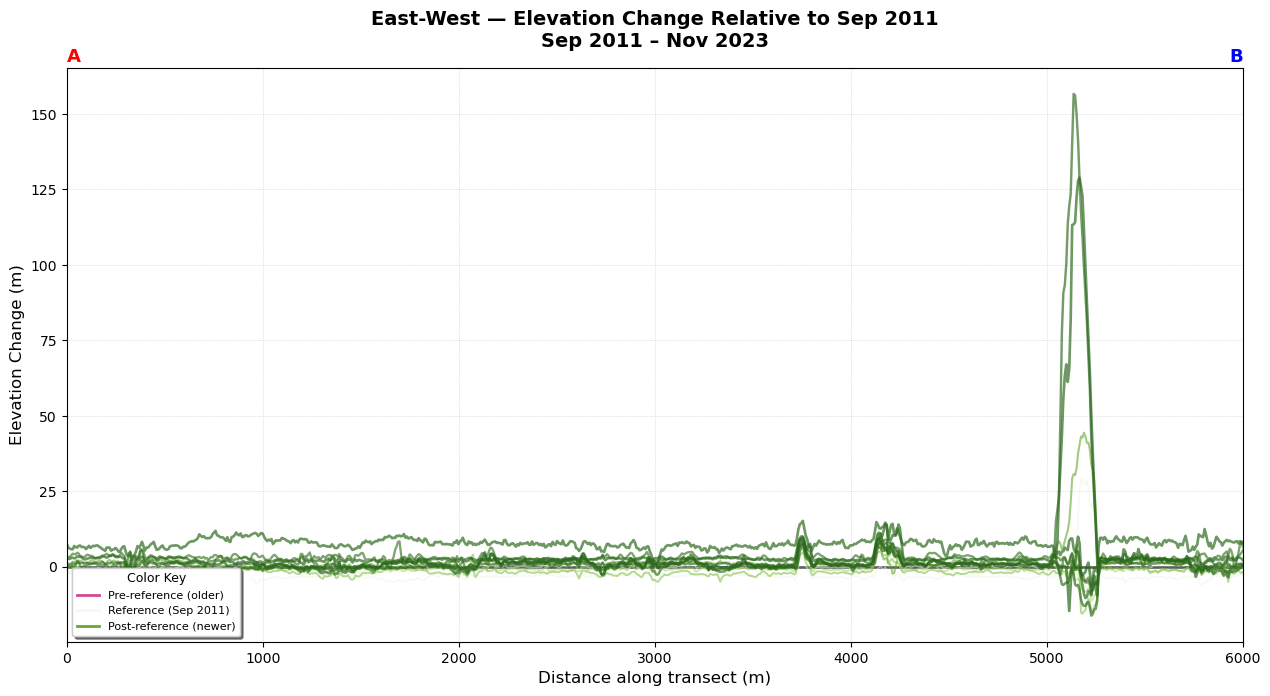

  ✗ Error in difference plot: expected str, bytes or os.PathLike object, not Figure
  Generating difference heatmap...
Heatmap saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/transects_combined/heatmap_East-West_-48.054_60.999_-47.946_61.001-2011-2026_None.png


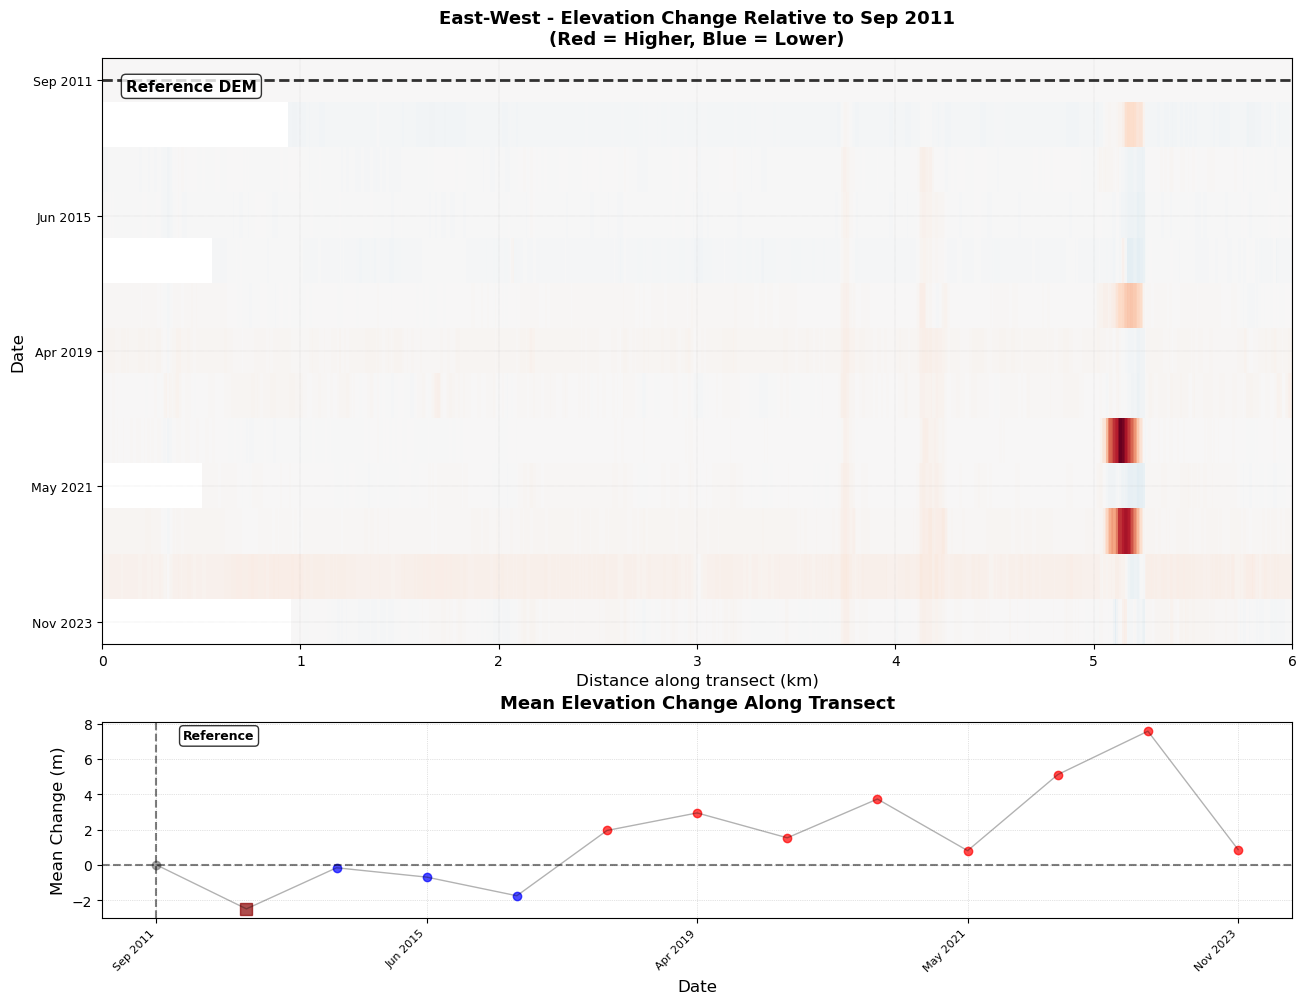

  ✓ Heatmap saved: heatmap_East-West_-48.054_60.999_-47.946_61.001-2011-2026_None.png
  ✓ All plots generated for East-West

ALL PLOTS COMPLETE

────────────────────────────────────────────────────────────────────────────────
PLOTS FOR: North-South
────────────────────────────────────────────────────────────────────────────────

  Combined Profiles:


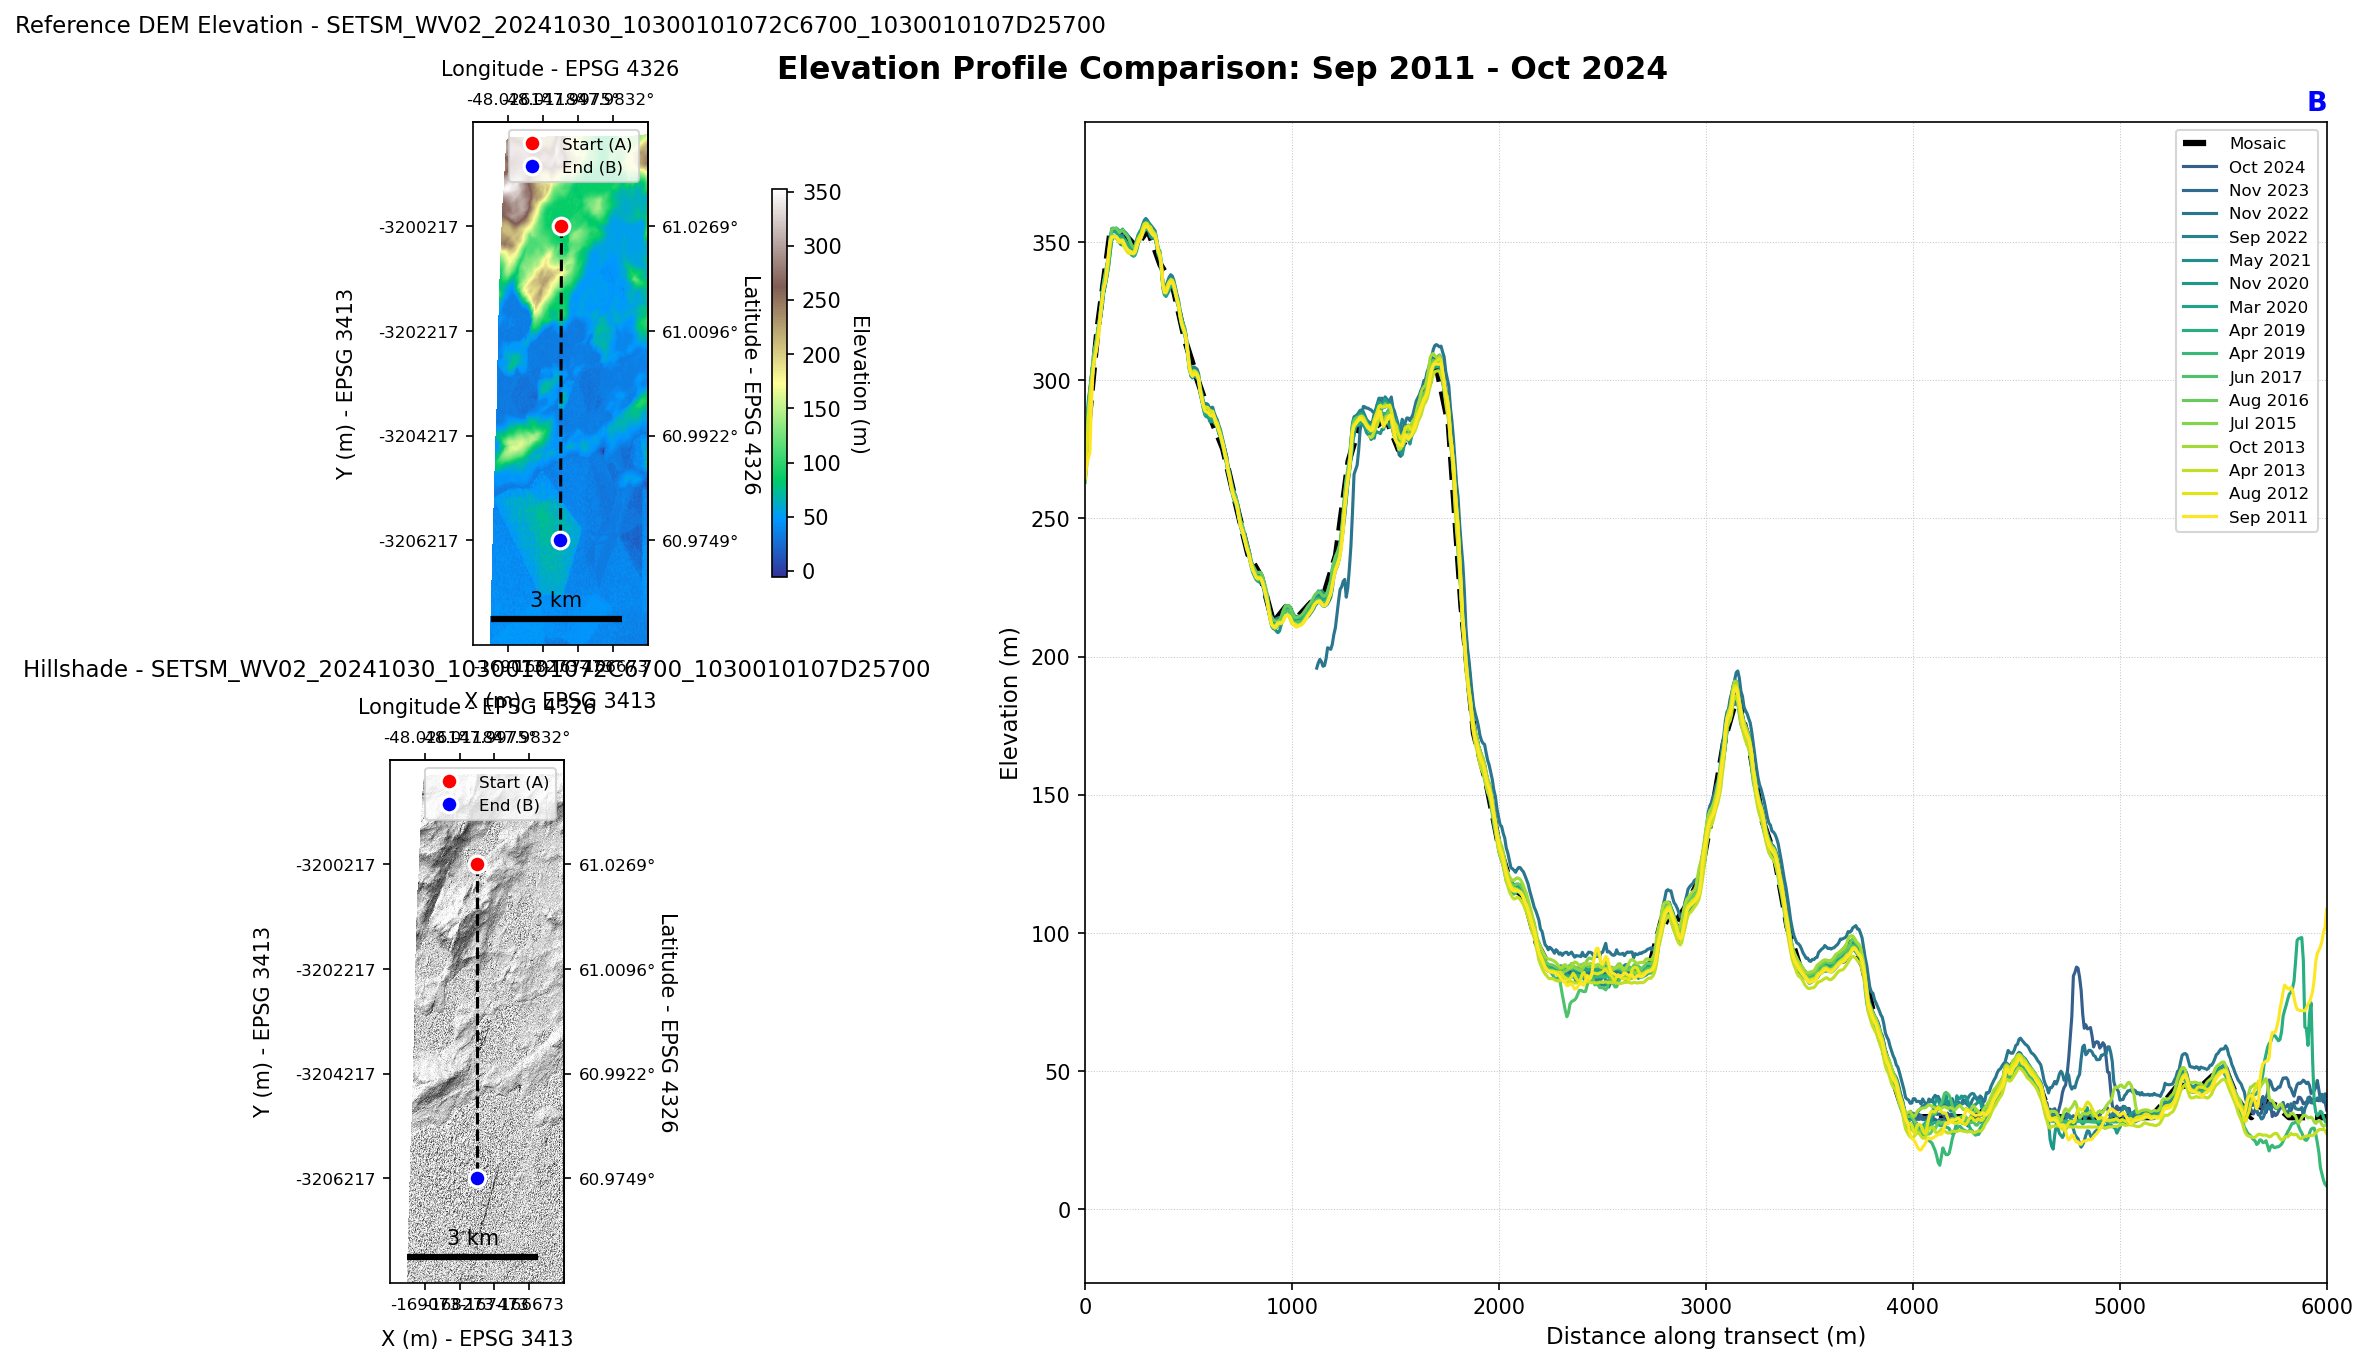


  Relative Differences: Not available

  Difference Heatmap:


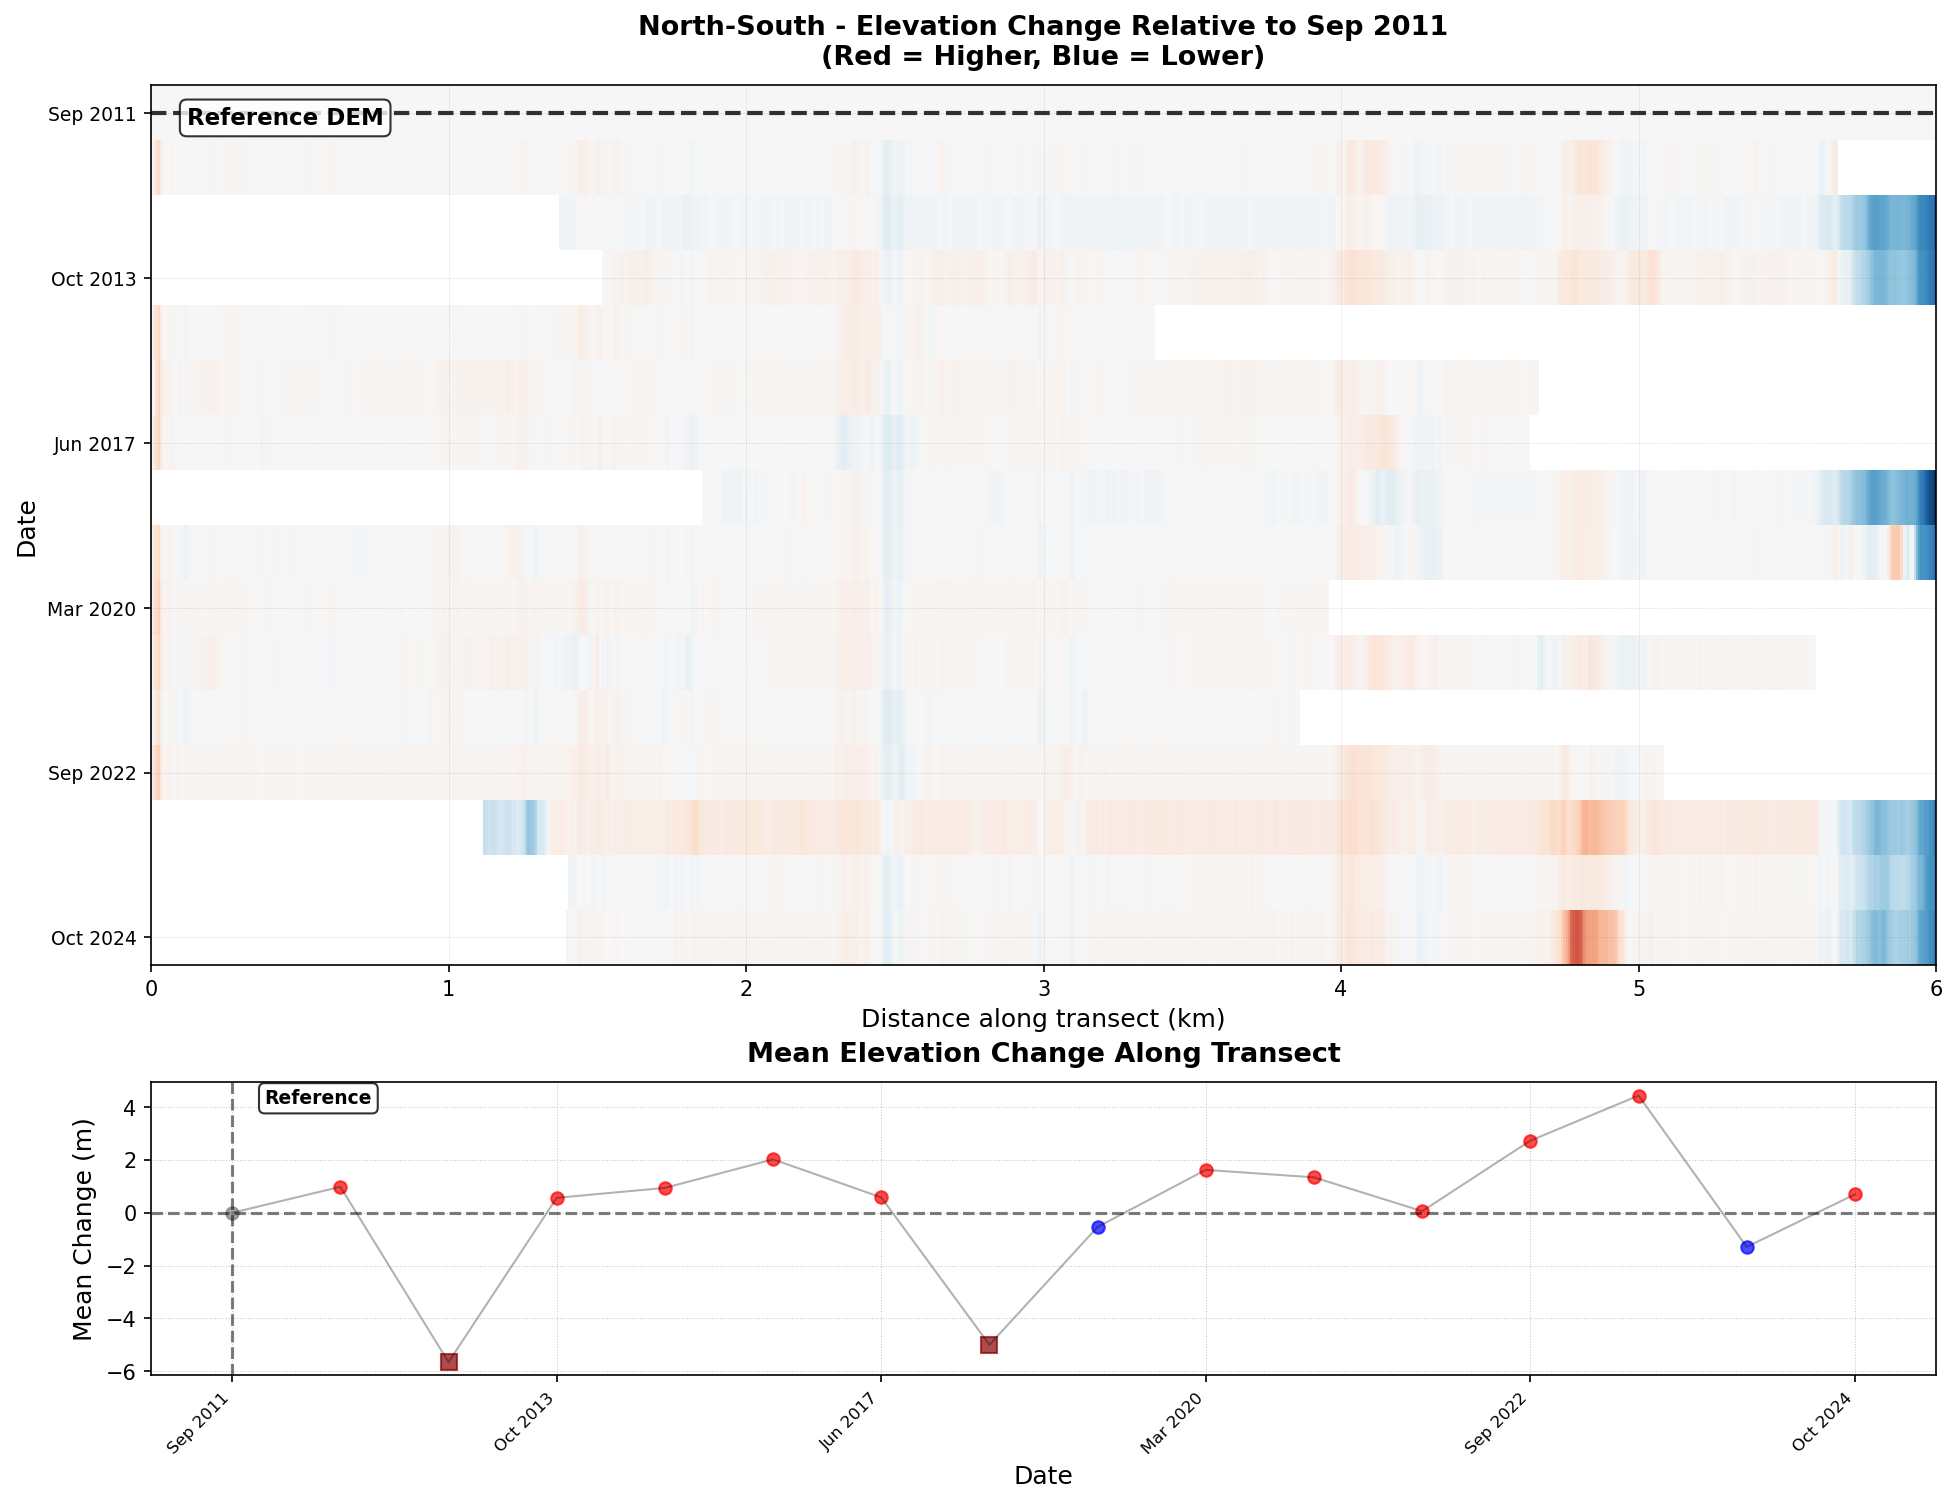


────────────────────────────────────────────────────────────────────────────────
PLOTS FOR: East-West
────────────────────────────────────────────────────────────────────────────────

  Combined Profiles:


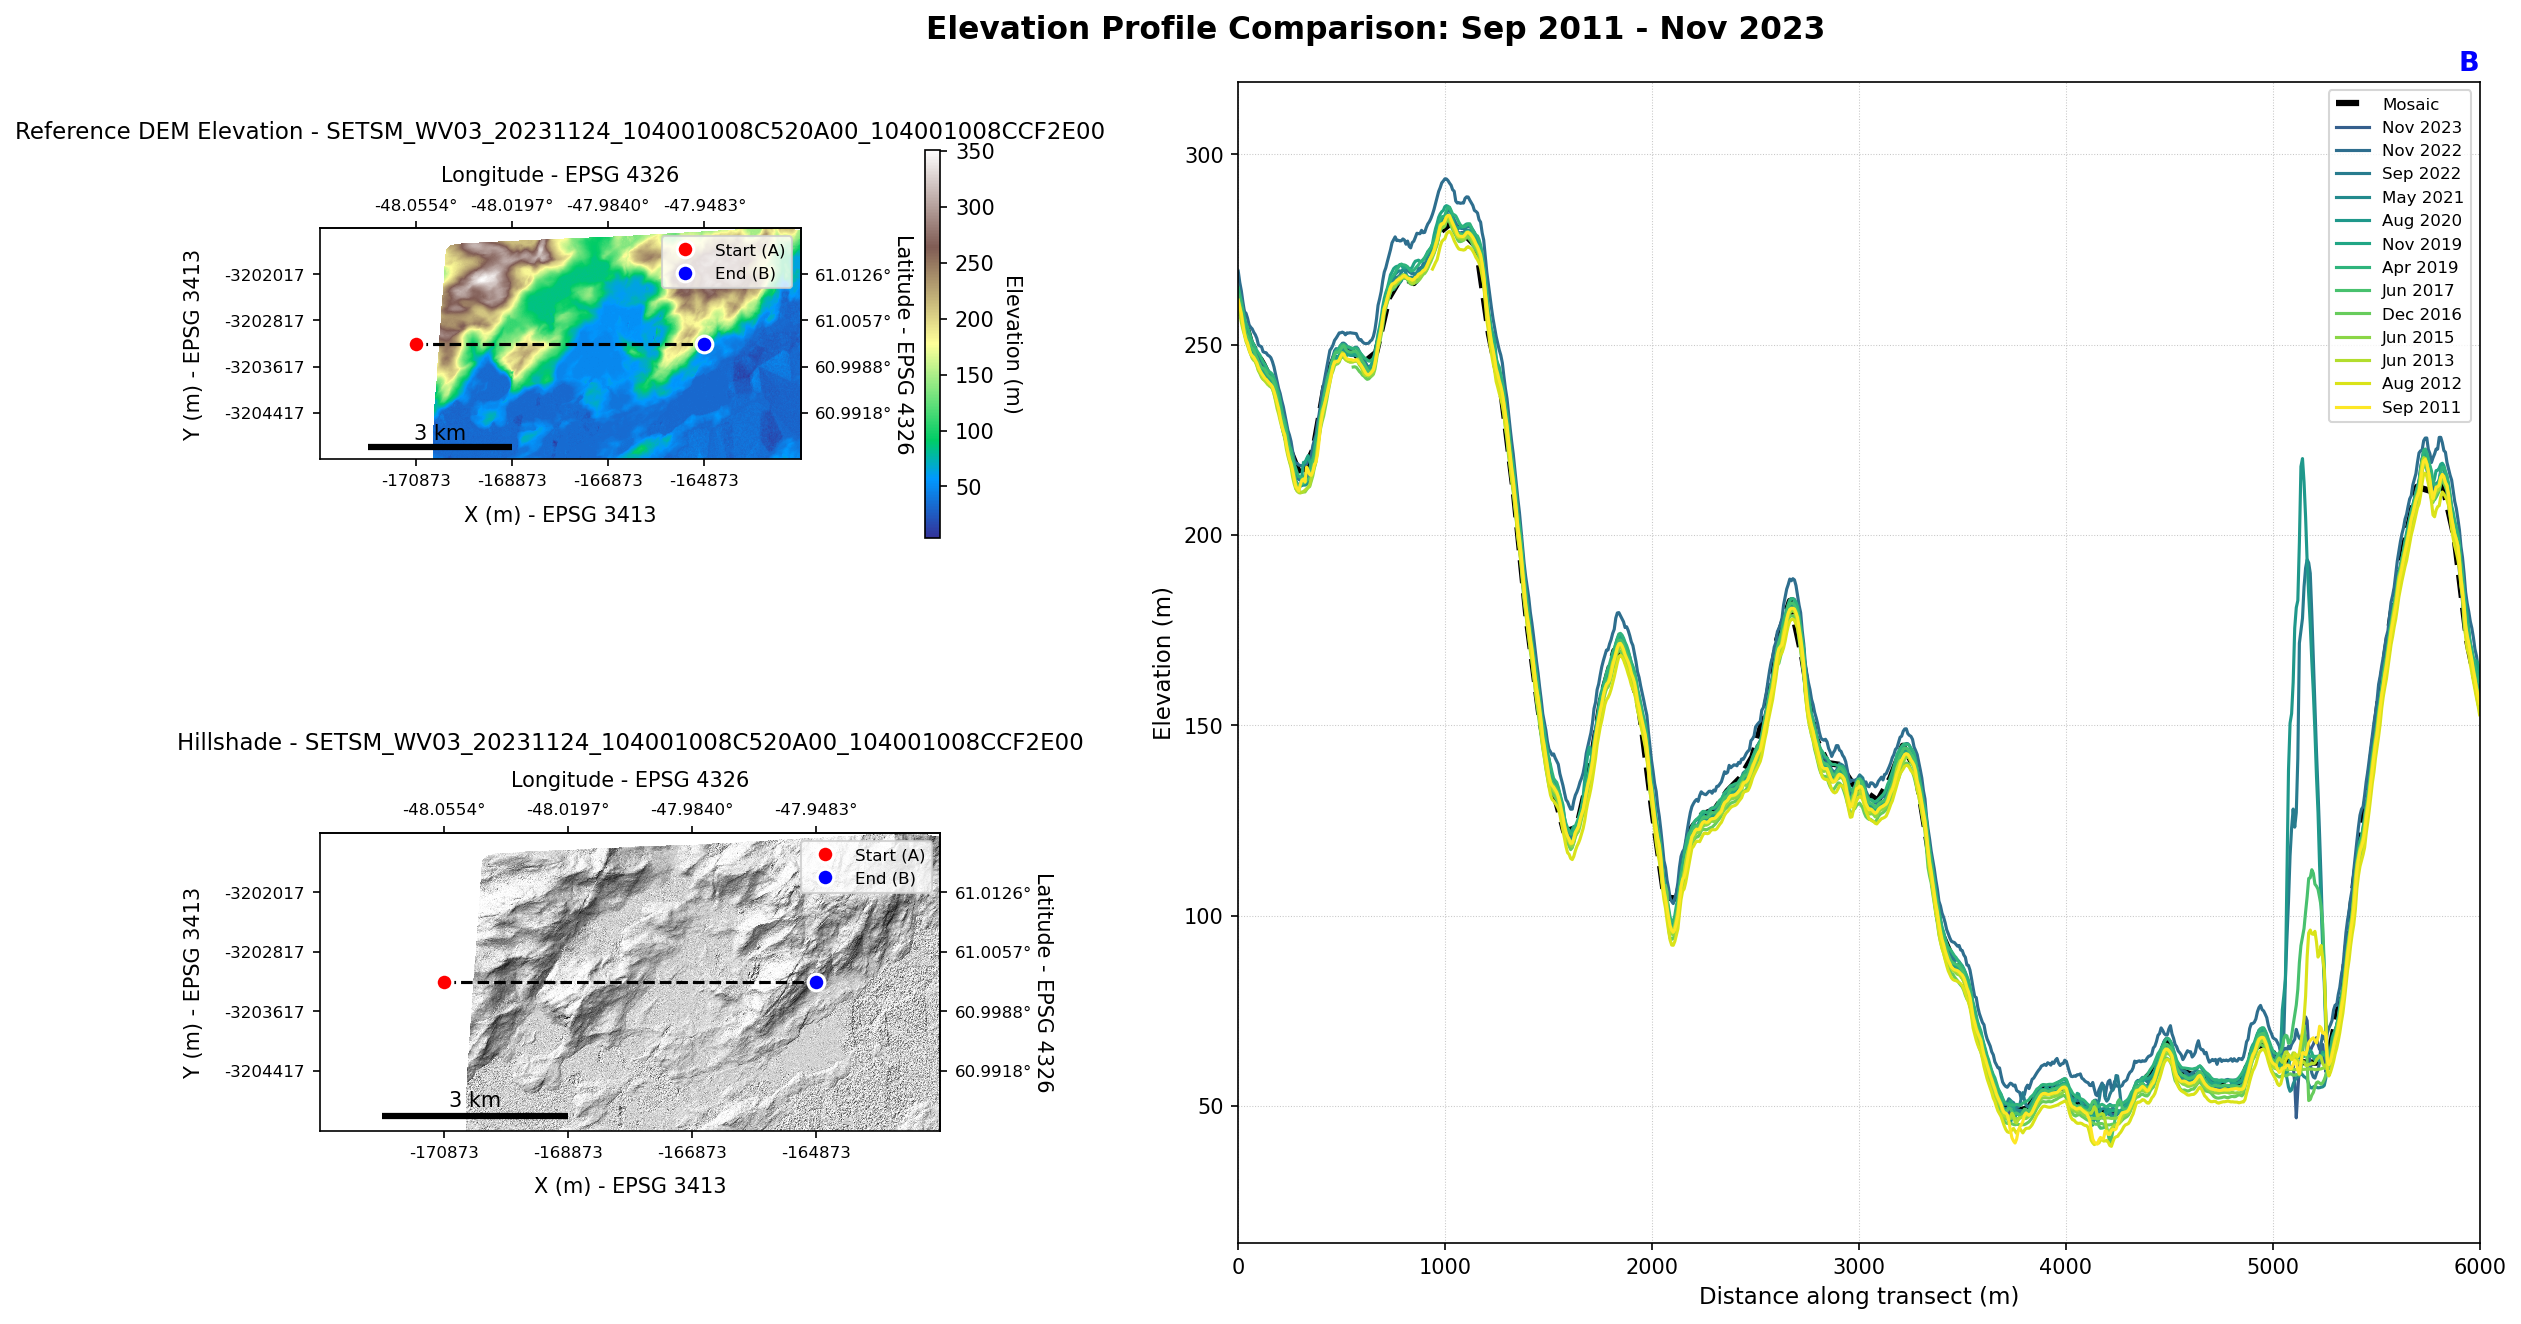


  Relative Differences: Not available

  Difference Heatmap:


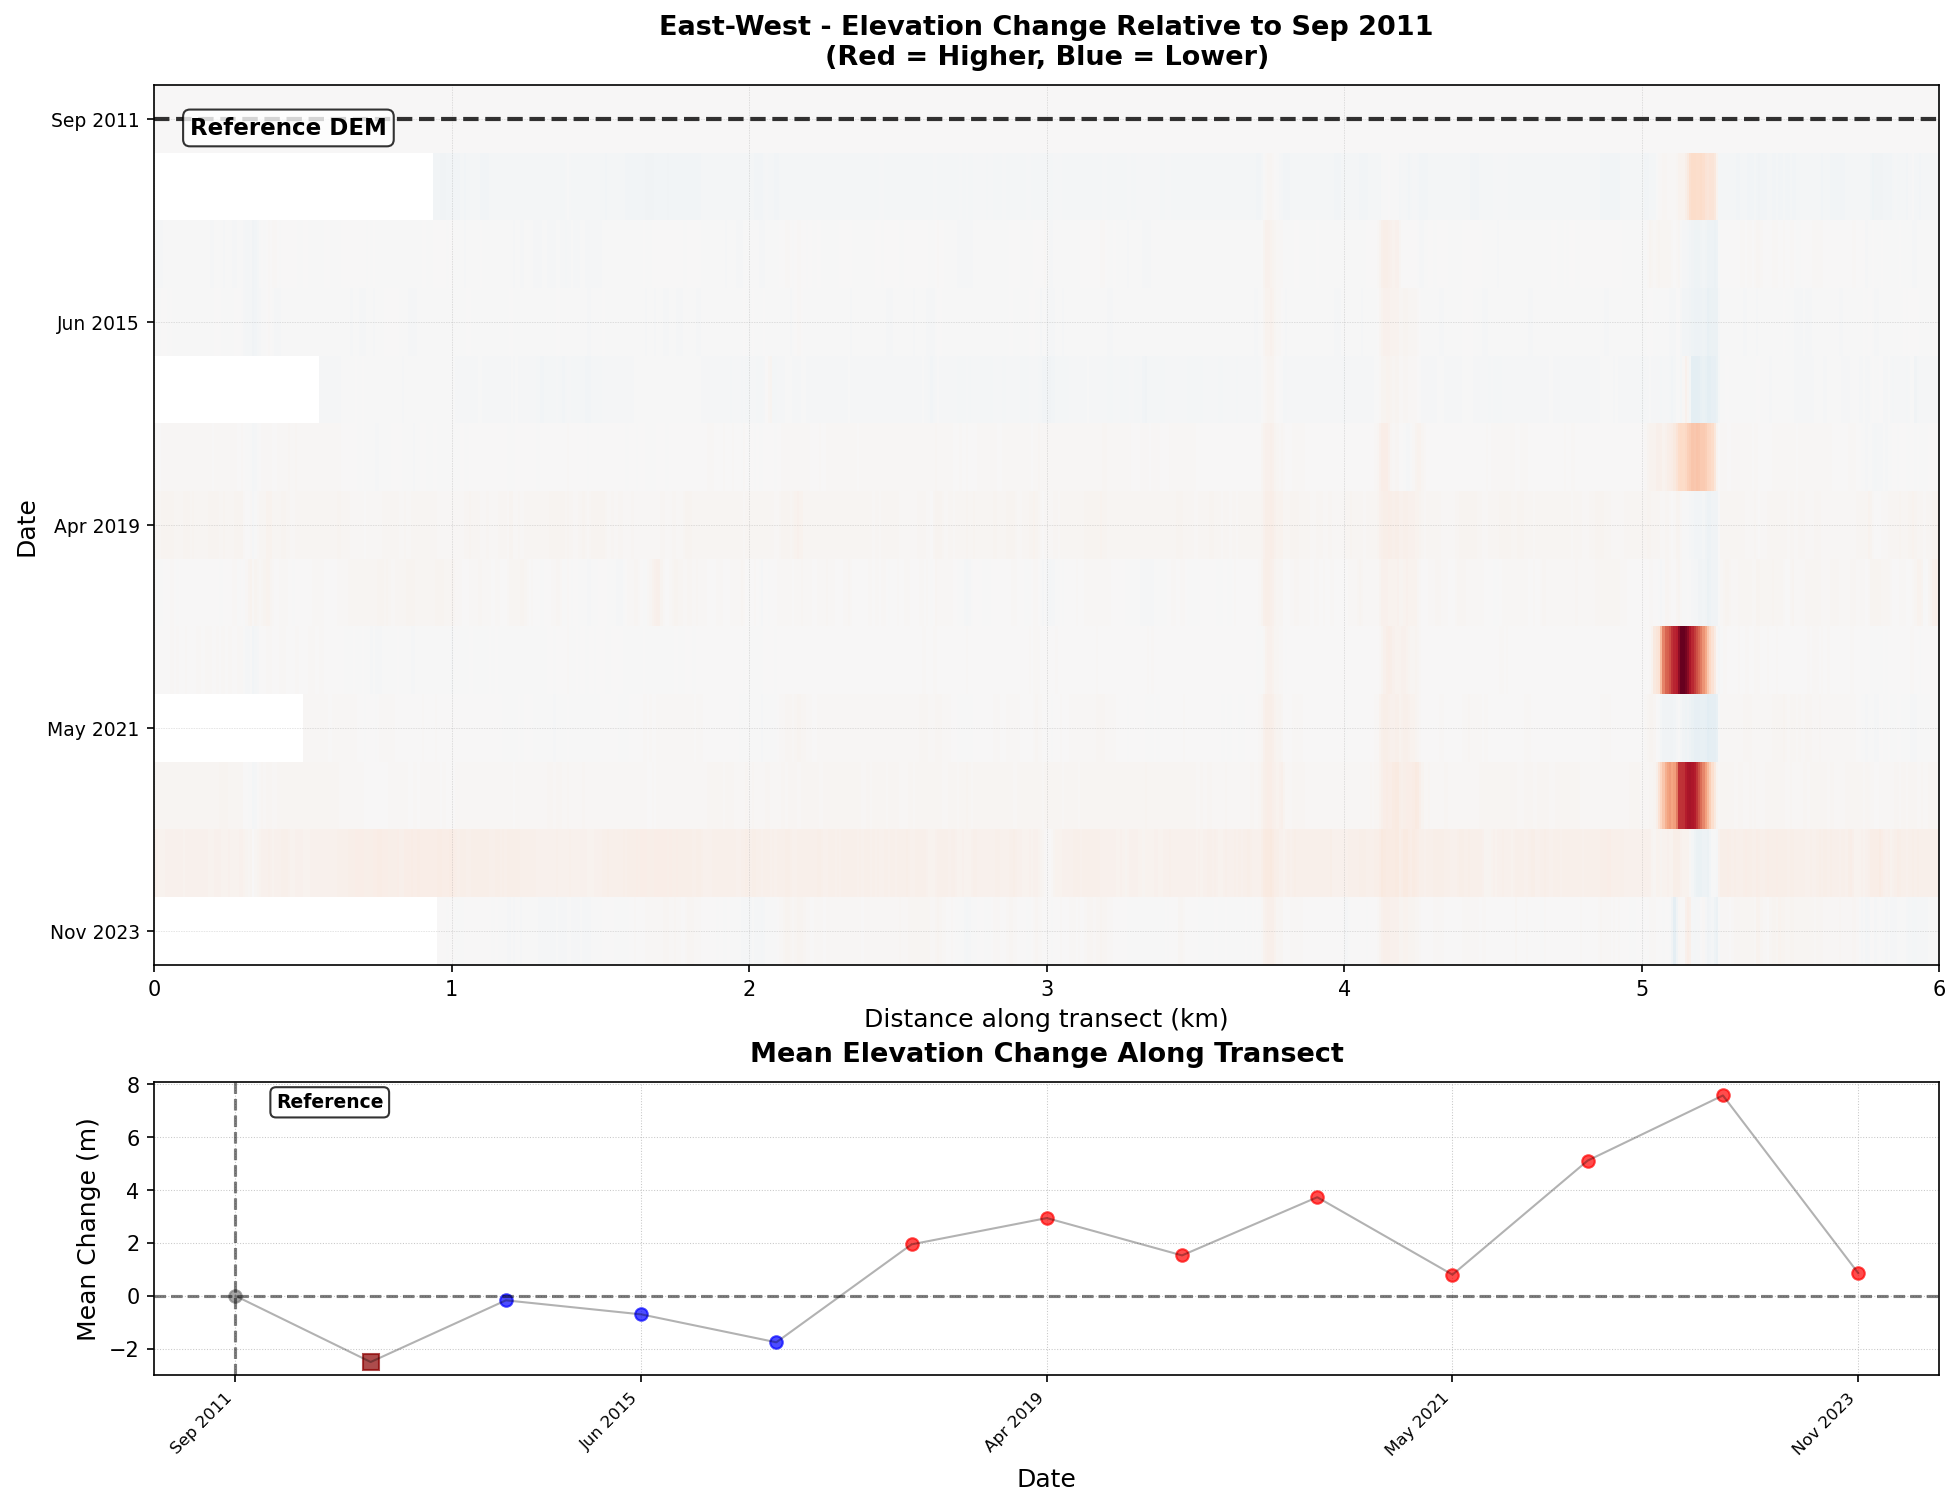


COORDINATE VERIFICATION

Plot bounds (EPSG:3413):
  left=-169873.5, right=-165873.5
  bottom=-3208217.3, top=-3198217.3
  width=4000m, height=10000m
WGS84 extent:
  lon: [-48.040412, -47.959711]
  lat: [60.955784, 61.044217]

Meridians: [-48.04041173 -48.02427163 -48.00813154 -47.99199145 -47.97585135
 -47.95971126]
Parallels: [60.95578376 60.97347033 60.9911569  61.00884347 61.02653004 61.04421661]


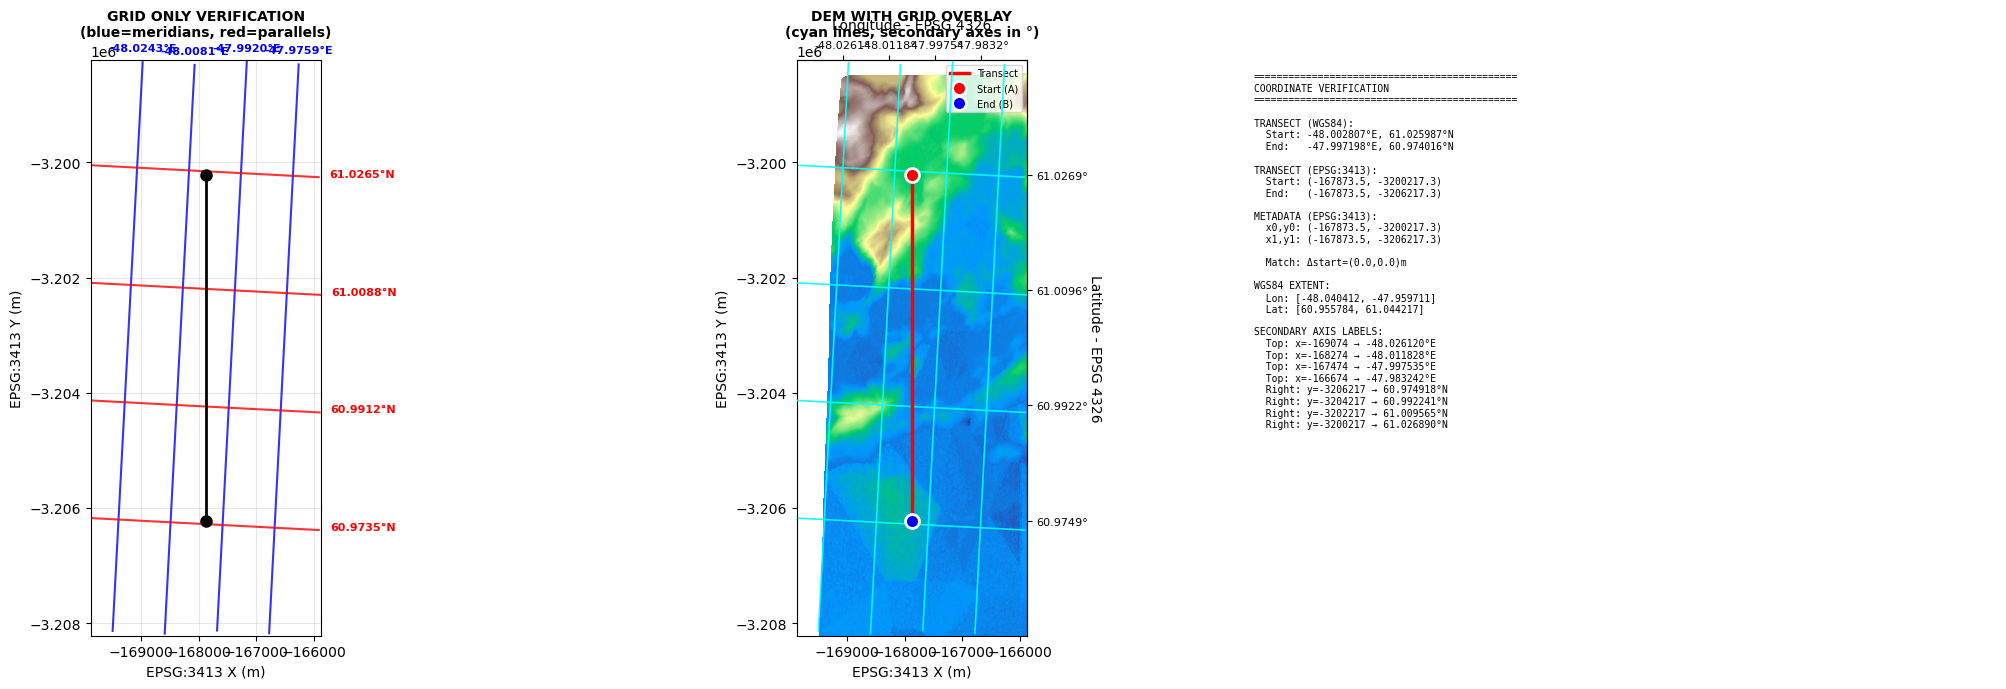


VISUAL CHECK:
Panel 1 (left):  Grid lines on white background
  - Blue vertical-ish lines = meridians (constant longitude)
  - Red horizontal-ish lines = parallels (constant latitude)

Panel 2 (center): Grid overlaid on DEM
  - Cyan lines should be visible on top of the terrain
  - Secondary axis labels (top/right) should match cyan labels


In [6]:
# Cell 6: Generate All Plots
"""
## Elevation Profile Plots
Generate combined profile plots, heatmaps, and relative change plots
for each transect. Works with both single and batch mode.
"""

from analysis import (
    plot_combined_profiles,
    plot_relative_differences,
    plot_difference_heatmap,
    verify_coordinate_transforms,
)
from IPython.display import Image, display
import os

# Determine mode
if 'all_transect_results' in locals() and isinstance(all_transect_results, list):
    batch_mode = True
    transect_list = all_transect_results
    print(f"Batch mode: generating plots for {len(transect_list)} transects\n")
else:
    batch_mode = False
    # Build a single-entry list for consistent processing
    lake_name = LAKE_NAME if 'LAKE_NAME' in locals() else None
    profiles_data = all_profiles if 'all_profiles' in locals() else profiles
    
    transect_list = [{
        'lake_name': lake_name or 'Transect',
        'profiles': profiles_data,
        'profiles_filtered': profiles_data,
        'transect_coords': profiles_data.get('transect_coords', ((0,0), (0,0))),
    }]
    print("Single transect mode\n")

# Process each transect
for i, transect_data in enumerate(transect_list):
    lake_name = transect_data.get('lake_name', f'Transect_{i+1}')
    
    # Use filtered profiles if available, otherwise original
    profiles_to_plot = transect_data.get('profiles_filtered', transect_data.get('profiles'))
    
    if not profiles_to_plot or not profiles_to_plot.get('profiles'):
        print(f"  ⚠️ {lake_name}: No profiles to plot - skipping")
        continue
    
    n_profiles = len(profiles_to_plot['profiles'])
    
    print(f"\n{'='*80}")
    print(f"PLOTTING: {lake_name} ({n_profiles} profiles)")
    print(f"{'='*80}")
    
    # ── Plot 1: Combined Elevation Profiles ──
    print(f"\n  Generating combined profile plot...")
    try:
        plot_path = plot_combined_profiles(
            profiles_to_plot,
            coreg_mode=COREG_MODE,
            lake_name=lake_name,
            margin_km=MARGIN_KM if 'MARGIN_KM' in locals() else 2,
        )
        transect_data['plot_combined_path'] = plot_path
        print(f"  ✓ Combined plot saved: {os.path.basename(plot_path)}")
    except Exception as e:
        print(f"  ✗ Error in combined plot: {e}")
        transect_data['plot_combined_path'] = None
    
    # ── Plot 2: Relative Differences ──
    print(f"  Generating relative differences plot...")
    try:
        diff_path = plot_relative_differences(
            profiles_to_plot,
            coreg_mode=COREG_MODE,
            lake_name=lake_name,
            output_path=OUTPUT_DIR,
        )
        transect_data['plot_diff_path'] = diff_path
        print(f"  ✓ Difference plot saved: {os.path.basename(diff_path) if diff_path else 'N/A'}")
    except Exception as e:
        print(f"  ✗ Error in difference plot: {e}")
        transect_data['plot_diff_path'] = None
    
    # ── Plot 3: Difference Heatmap ──
    print(f"  Generating difference heatmap...")
    try:
        heatmap_path = plot_difference_heatmap(
            profiles_to_plot,
            reference_year=None,
            lake_name=lake_name,
            output_path=OUTPUT_DIR,
        )
        transect_data['plot_heatmap_path'] = heatmap_path
        print(f"  ✓ Heatmap saved: {os.path.basename(heatmap_path) if heatmap_path else 'N/A'}")
    except Exception as e:
        print(f"  ✗ Error in heatmap: {e}")
        transect_data['plot_heatmap_path'] = None
    
    print(f"  ✓ All plots generated for {lake_name}")

print(f"\n{'='*80}")
print(f"ALL PLOTS COMPLETE")
print(f"{'='*80}")

# ── Display first few plots ──
n_show = min(3, len(transect_list))

for i in range(n_show):
    transect_data = transect_list[i]
    lake_name = transect_data.get('lake_name', f'Transect_{i+1}')
    
    print(f"\n{'─'*80}")
    print(f"PLOTS FOR: {lake_name}")
    print(f"{'─'*80}")
    
    for plot_type, plot_key in [
        ('Combined Profiles', 'plot_combined_path'),
        ('Relative Differences', 'plot_diff_path'),
        ('Difference Heatmap', 'plot_heatmap_path'),
    ]:
        plot_path = transect_data.get(plot_key)
        if plot_path and os.path.exists(plot_path):
            print(f"\n  {plot_type}:")
            display(Image(filename=plot_path))
        else:
            print(f"\n  {plot_type}: Not available")

if len(transect_list) > n_show:
    print(f"\n... and {len(transect_list) - n_show} more transects")
    print(f"Check the output directory for all plots:")
    print(f"  {os.path.join(OUTPUT_DIR, 'transects_combined')}")

# ── Coordinate Verification (first transect only) ──
print(f"\n{'='*80}")
print(f"COORDINATE VERIFICATION")
print(f"{'='*80}")

# Verify first transect
first_transect = transect_list[0]
profiles_to_verify = first_transect.get('profiles_filtered', first_transect.get('profiles'))

if profiles_to_verify and profiles_to_verify.get('profiles'):
    verify_coordinate_transforms(profiles_to_verify, margin_km=2)
else:
    print("No profile data available for verification")

TEMPORAL EVOLUTION ANALYSIS

────────────────────────────────────────────────────────────────────────────────
1. OVERALL ELEVATION TREND
────────────────────────────────────────────────────────────────────────────────
Mean elevation trend: +0.41 m/year
Total change over period: +5.04 m
R² = 0.034, p = 0.5464
Assessment: 📈 Thickening trend

────────────────────────────────────────────────────────────────────────────────
2. SPATIAL CHANGE RATE ALONG TRANSECT
────────────────────────────────────────────────────────────────────────────────
Total points along transect: 800
Points with significant change (p<0.05): 577 (72.1%)
Significant thinning (<-0.1 m/yr): 0 points
Significant thickening (>+0.1 m/yr): 577 points

────────────────────────────────────────────────────────────────────────────────
3. LOCALIZED CHANGE DETECTION
────────────────────────────────────────────────────────────────────────────────

Potential thickening hotspots: 25

  Region 1:
    Distance: 0 – 293 m (40 points)
   

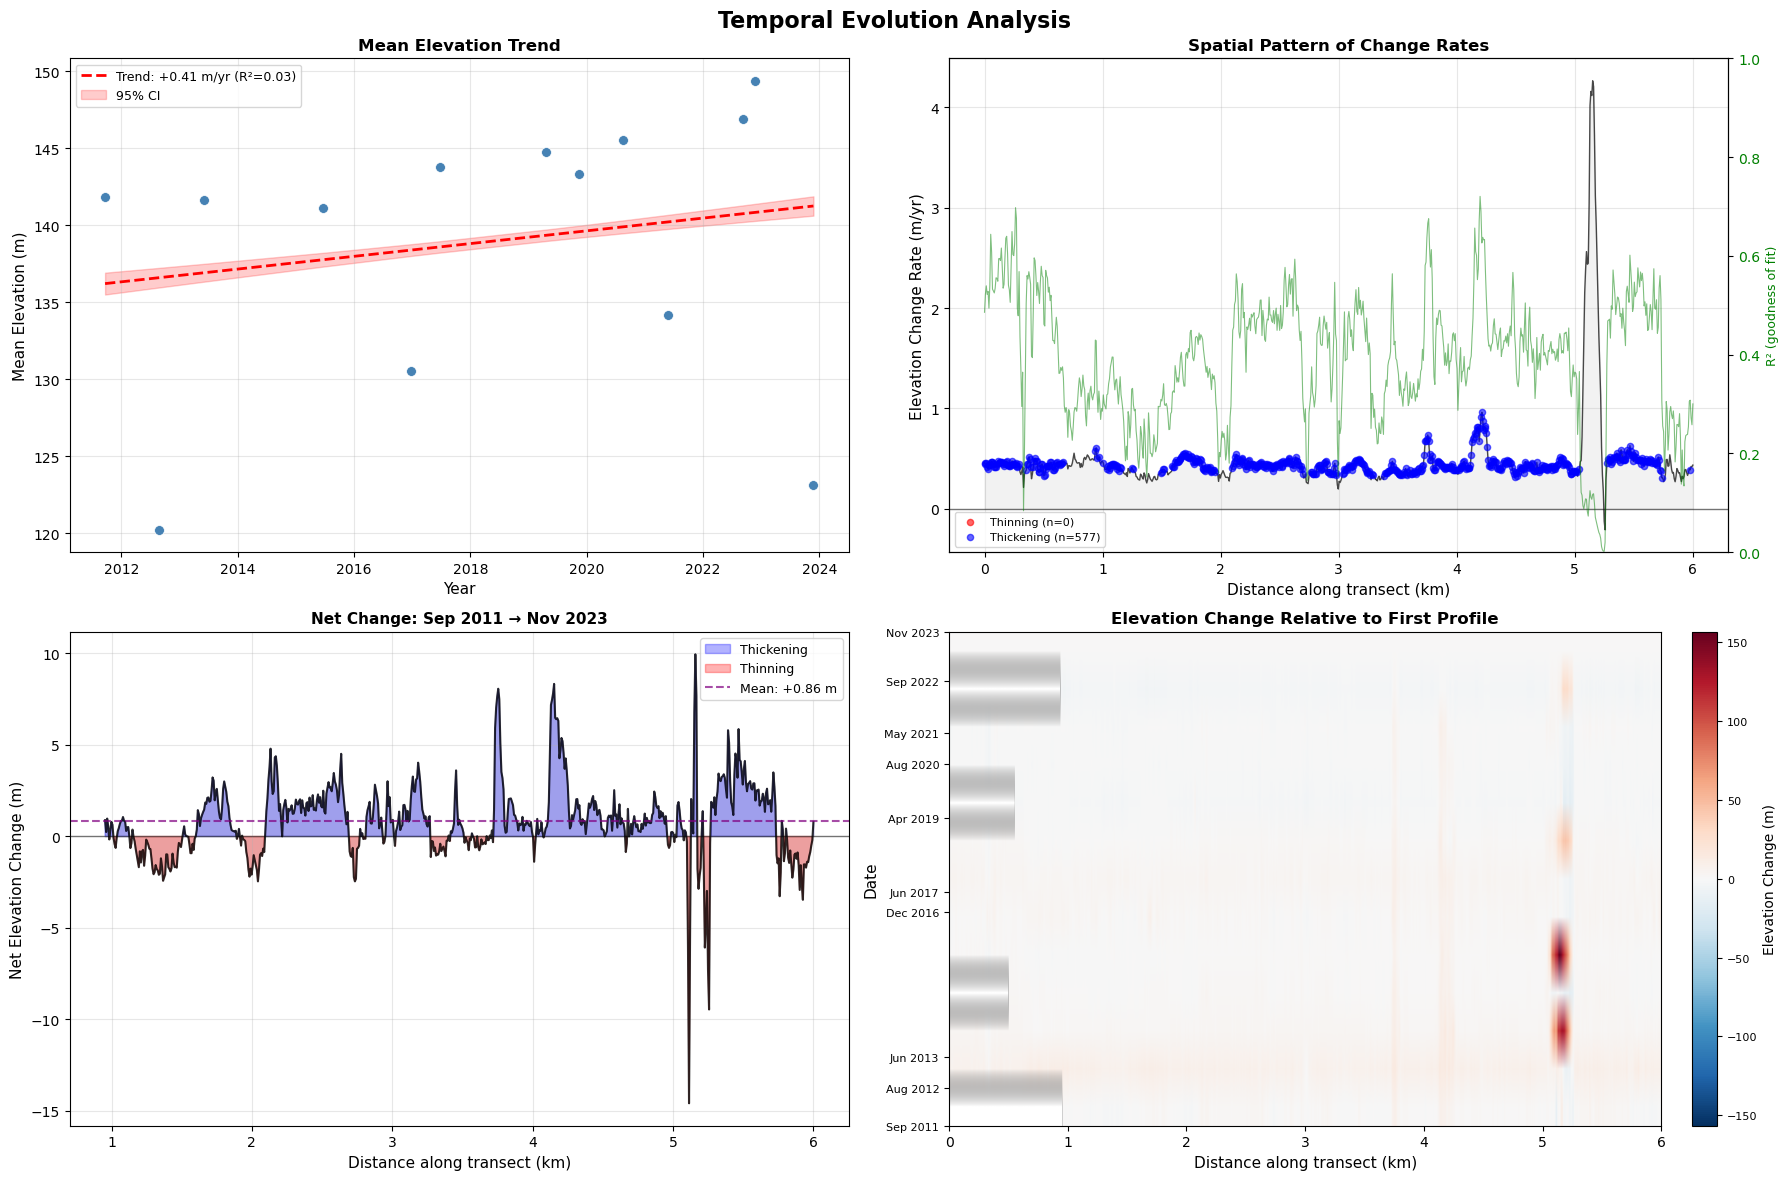


SUMMARY

Metric                                                  Value
--------------------------------------------------------------
Overall trend                                           +0.41 m/yr
Total change                                            +5.04 m
Statistical significance (p)                           0.5464
Mean net change (first–last)                            +0.86 m
Max thinning (single point)                            -14.58 m
Max thickening (single point)                           +9.95 m
Points with significant change                            577 / 800
Potential thinning hotspots                                 0
Potential thickening hotspots                              25

Analysis complete! Interpret with caution — check data quality first.


In [7]:
# Cell 6: Temporal evolution analysis
"""
Temporal Evolution & Change Detection
Analyze how elevation profiles change over time to detect:
- Overall thinning/thickening trends
- Localized changes (potential subglacial lake activity)
- Spatial patterns in elevation change rates
"""
from analysis import extract_date_obj, extract_date_label
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

print("=" * 80)
print("TEMPORAL EVOLUTION ANALYSIS")
print("=" * 80)

# Use the last transect that has profiles (filtered ones if available)
if 'all_transect_results' in locals():
    _with_profiles = [t.get('profiles_filtered', t['profiles']) for t in all_transect_results
                      if t.get('profiles_filtered', t['profiles'])['profiles']]
    if _with_profiles:
        all_profiles = _with_profiles[-1]
if not all_profiles.get('profiles'):
    raise ValueError("No transect has profiles to analyse")

# Sort profiles by date
profiles_sorted = sorted(
    all_profiles['profiles'],
    key=lambda x: extract_date_obj(x['metadata']['dem_name'])
)

# Extract dates and create common distance grid
dates_list = [extract_date_obj(p['metadata']['dem_name']) for p in profiles_sorted]
distances = profiles_sorted[0]['transect']  # Use first profile as reference distance

# Interpolate all profiles to common distance grid for comparison
n_profiles = len(profiles_sorted)
n_points = len(distances)
elevation_matrix = np.full((n_profiles, n_points), np.nan)

for i, profile in enumerate(profiles_sorted):
    elevations = np.array(profile['profile_values'])
    valid = ~np.isnan(elevations)
    
    if np.sum(valid) > 2:
        # Interpolate to common grid (handle missing values)
        elevation_matrix[i, :] = np.interp(
            distances, 
            profile['transect'][valid], 
            elevations[valid],
            left=np.nan, right=np.nan
        )

# ──────────────────────────────────────────────────────────────────────────
# 1. OVERALL TREND: Mean elevation change over time
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 80)
print("1. OVERALL ELEVATION TREND")
print("─" * 80)

# Calculate mean elevation for each profile (using valid points only)
mean_elevations = np.nanmean(elevation_matrix, axis=1)
valid_means = ~np.isnan(mean_elevations)

# Dates as decimal years (used by every section below)
years = np.array([d.year + d.timetuple().tm_yday / 365.25 
                  for d in dates_list])

if np.sum(valid_means) >= 3:
    # Linear regression: elevation vs time
    valid_idx = np.where(valid_means)[0]
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        years[valid_idx], mean_elevations[valid_idx]
    )
    
    total_change = slope * (years[-1] - years[0])
    
    print(f"Mean elevation trend: {slope:+.2f} m/year")
    print(f"Total change over period: {total_change:+.2f} m")
    print(f"R² = {r_value**2:.3f}, p = {p_value:.4f}")
    
    if slope < -0.1:
        trend_text = "⚠️  SIGNIFICANT THINNING DETECTED"
    elif slope < -0.02:
        trend_text = "📉 Moderate thinning trend"
    elif slope > 0.02:
        trend_text = "📈 Thickening trend"
    else:
        trend_text = "➡️  Relatively stable"
    
    print(f"Assessment: {trend_text}")
else:
    print("Insufficient valid data for trend analysis")

# ──────────────────────────────────────────────────────────────────────────
# 2. SPATIAL CHANGE RATE: Elevation change rate along transect
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 80)
print("2. SPATIAL CHANGE RATE ALONG TRANSECT")
print("─" * 80)

# Calculate change rate at each point along transect
change_rates = np.full(n_points, np.nan)
change_pvalues = np.full(n_points, np.nan)
point_r_squared = np.full(n_points, np.nan)

for i in range(n_points):
    point_elevations = elevation_matrix[:, i]
    valid = ~np.isnan(point_elevations)
    
    if np.sum(valid) >= 5:  # Need at least 5 points for regression
        slope_i, _, r_i, p_i, _ = stats.linregress(
            years[valid], point_elevations[valid]
        )
        change_rates[i] = slope_i
        change_pvalues[i] = p_i
        point_r_squared[i] = r_i**2

# Identify significant changes
significant = change_pvalues < 0.05
thinning_points = significant & (change_rates < -0.1)
thickening_points = significant & (change_rates > 0.1)

print(f"Total points along transect: {n_points}")
print(f"Points with significant change (p<0.05): {np.sum(significant)} ({100*np.sum(significant)/n_points:.1f}%)")
print(f"Significant thinning (<-0.1 m/yr): {np.sum(thinning_points)} points")
print(f"Significant thickening (>+0.1 m/yr): {np.sum(thickening_points)} points")

# ──────────────────────────────────────────────────────────────────────────
# 3. LOCALIZED CHANGE DETECTION (potential subglacial lake activity)
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 80)
print("3. LOCALIZED CHANGE DETECTION")
print("─" * 80)

# Look for clusters of rapid change (potential lake activity)
from scipy.ndimage import label

# Find contiguous regions of significant thinning
if np.sum(thinning_points) > 0:
    thinning_regions, n_thinning = label(thinning_points)
    
    print(f"Potential thinning hotspots: {n_thinning}")
    
    for region_id in range(1, n_thinning + 1):
        region_mask = thinning_regions == region_id
        region_size = np.sum(region_mask)
        
        if region_size >= 3:  # At least 3 contiguous points
            region_start = distances[np.where(region_mask)[0][0]]
            region_end = distances[np.where(region_mask)[0][-1]]
            region_mean_rate = np.nanmean(change_rates[region_mask])
            region_max_rate = np.nanmin(change_rates[region_mask])
            
            print(f"\n  Region {region_id}:")
            print(f"    Distance: {region_start:.0f} – {region_end:.0f} m ({region_size} points)")
            print(f"    Mean rate: {region_mean_rate:+.2f} m/yr")
            print(f"    Max thinning: {region_max_rate:+.2f} m/yr")
            
            # Check if rate exceeds typical thinning (potential lake drainage)
            if region_max_rate < -0.5:
                print(f"    ⚠️  RAPID THINNING — possible subglacial lake drainage!")
            elif region_max_rate < -0.2:
                print(f"    🔍 Notable thinning — worth investigating")

# Find contiguous regions of significant thickening
if np.sum(thickening_points) > 0:
    thickening_regions, n_thickening = label(thickening_points)
    
    print(f"\nPotential thickening hotspots: {n_thickening}")
    
    for region_id in range(1, n_thickening + 1):
        region_mask = thickening_regions == region_id
        region_size = np.sum(region_mask)
        
        if region_size >= 3:
            region_start = distances[np.where(region_mask)[0][0]]
            region_end = distances[np.where(region_mask)[0][-1]]
            region_mean_rate = np.nanmean(change_rates[region_mask])
            
            print(f"\n  Region {region_id}:")
            print(f"    Distance: {region_start:.0f} – {region_end:.0f} m ({region_size} points)")
            print(f"    Mean rate: {region_mean_rate:+.2f} m/yr")
            
            if region_mean_rate > 0.5:
                print(f"    💧 Possible subglacial lake filling!")

# ──────────────────────────────────────────────────────────────────────────
# 4. ELEVATION CHANGE BETWEEN FIRST AND LAST PROFILE
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 80)
print("4. NET CHANGE: First vs Last Profile")
print("─" * 80)

# Compare first and last valid profiles
first_valid_idx = np.where(valid_means)[0][0]
last_valid_idx = np.where(valid_means)[0][-1]

first_profile = elevation_matrix[first_valid_idx, :]
last_profile = elevation_matrix[last_valid_idx, :]

# Calculate point-by-point difference
net_change = last_profile - first_profile
valid_change = ~np.isnan(net_change)

if np.sum(valid_change) > 0:
    print(f"First profile: {extract_date_label(profiles_sorted[first_valid_idx]['metadata']['dem_name'])}")
    print(f"Last profile:  {extract_date_label(profiles_sorted[last_valid_idx]['metadata']['dem_name'])}")
    print(f"Time span: {(years[last_valid_idx] - years[first_valid_idx]):.1f} years")
    print(f"Net change statistics along transect:")
    print(f"  Mean: {np.nanmean(net_change):+.2f} m")
    print(f"  Median: {np.nanmedian(net_change):+.2f} m")
    print(f"  Min: {np.nanmin(net_change):+.2f} m (max thinning)")
    print(f"  Max: {np.nanmax(net_change):+.2f} m (max thickening)")
    print(f"  Std: {np.nanstd(net_change):.2f} m")
    
    # Percentage of transect showing thinning vs thickening
    pct_thinning = 100 * np.sum(net_change[valid_change] < 0) / np.sum(valid_change)
    pct_thickening = 100 * np.sum(net_change[valid_change] > 0) / np.sum(valid_change)
    
    print(f"\n  Thinning: {pct_thinning:.1f}% of transect")
    print(f"  Thickening: {pct_thickening:.1f}% of transect")

# ──────────────────────────────────────────────────────────────────────────
# 5. VISUALIZATION: Multi-panel temporal analysis plot
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 80)
print("5. Generating temporal analysis visualization...")
print("─" * 80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Temporal Evolution Analysis', fontsize=16, fontweight='bold', y=0.98)

# Panel 1: Mean elevation over time
ax1 = axes[0, 0]
if np.sum(valid_means) >= 3:
    ax1.scatter(years[valid_means], mean_elevations[valid_means], 
               c='steelblue', s=50, zorder=5, edgecolors='white', linewidth=0.5)
    
    # Trend line
    trend_y = slope * years[valid_idx] + intercept
    ax1.plot(years[valid_idx], trend_y, 'r--', linewidth=2, 
            label=f'Trend: {slope:+.2f} m/yr (R²={r_value**2:.2f})')
    
    # Confidence band
    n = len(valid_idx)
    conf_interval = std_err * 1.96 * np.sqrt(1/n + (years[valid_idx] - np.mean(years[valid_idx]))**2 / 
                                             np.sum((years[valid_idx] - np.mean(years[valid_idx]))**2))
    ax1.fill_between(years[valid_idx], trend_y - conf_interval, trend_y + conf_interval,
                    alpha=0.2, color='red', label='95% CI')
    
    ax1.legend(fontsize=9)
    
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Mean Elevation (m)', fontsize=11)
ax1.set_title('Mean Elevation Trend', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Panel 2: Change rate along transect
ax2 = axes[0, 1]
dist_km = distances / 1000  # Convert to km

# Plot change rate
ax2.fill_between(dist_km, 0, change_rates, alpha=0.1, color='gray')
ax2.plot(dist_km, change_rates, 'k-', linewidth=1, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Highlight significant changes
if np.sum(significant) > 0:
    ax2.scatter(dist_km[thinning_points], change_rates[thinning_points], 
               c='red', s=20, alpha=0.6, label=f'Thinning (n={np.sum(thinning_points)})', zorder=5)
    ax2.scatter(dist_km[thickening_points], change_rates[thickening_points], 
               c='blue', s=20, alpha=0.6, label=f'Thickening (n={np.sum(thickening_points)})', zorder=5)
    ax2.legend(fontsize=8, loc='lower left')

# Add R² information
ax2_twin = ax2.twinx()
ax2_twin.plot(dist_km, point_r_squared, 'g-', linewidth=0.8, alpha=0.5, label='R²')
ax2_twin.set_ylabel('R² (goodness of fit)', fontsize=9, color='green')
ax2_twin.tick_params(axis='y', labelcolor='green')
ax2_twin.set_ylim(0, 1)

ax2.set_xlabel('Distance along transect (km)', fontsize=11)
ax2.set_ylabel('Elevation Change Rate (m/yr)', fontsize=11)
ax2.set_title('Spatial Pattern of Change Rates', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Panel 3: Net change (first vs last)
ax3 = axes[1, 0]
if np.sum(valid_change) > 0:
    ax3.fill_between(dist_km, 0, net_change, alpha=0.2, color='gray')
    ax3.plot(dist_km, net_change, 'k-', linewidth=1.5, alpha=0.8)
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Color regions by sign of change
    positive = net_change > 0
    negative = net_change < 0
    ax3.fill_between(dist_km, 0, net_change, 
                    where=positive, alpha=0.3, color='blue', label='Thickening')
    ax3.fill_between(dist_km, 0, net_change, 
                    where=negative, alpha=0.3, color='red', label='Thinning')
    
    # Add mean net change line
    mean_net = np.nanmean(net_change)
    ax3.axhline(y=mean_net, color='purple', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Mean: {mean_net:+.2f} m')
    
    ax3.legend(fontsize=9)

ax3.set_xlabel('Distance along transect (km)', fontsize=11)
ax3.set_ylabel('Net Elevation Change (m)', fontsize=11)
ax3.set_title(f'Net Change: {extract_date_label(profiles_sorted[first_valid_idx]["metadata"]["dem_name"])} → '
             f'{extract_date_label(profiles_sorted[last_valid_idx]["metadata"]["dem_name"])}', 
             fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Panel 4: Elevation change heatmap (time vs distance)
ax4 = axes[1, 1]

# Create heatmap of elevation changes relative to first profile
change_matrix = elevation_matrix - elevation_matrix[first_valid_idx, :]
change_matrix = np.ma.masked_invalid(change_matrix)

max_abs = np.nanmax(np.abs(change_matrix))
vlim = max(5, max_abs)

im = ax4.imshow(change_matrix, aspect='auto', cmap='RdBu_r',
               extent=[dist_km[0], dist_km[-1], years[0], years[-1]],
               vmin=-vlim, vmax=vlim, interpolation='bilinear')

# Format
date_labels = [extract_date_label(p['metadata']['dem_name']) for p in profiles_sorted]
n_labels = min(len(date_labels), 10)
tick_indices = np.linspace(0, len(date_labels)-1, n_labels, dtype=int)
tick_years = [years[i] for i in tick_indices]
tick_labels = [date_labels[i] for i in tick_indices]

ax4.set_yticks(tick_years)
ax4.set_yticklabels(tick_labels, fontsize=8)
ax4.set_xlabel('Distance along transect (km)', fontsize=11)
ax4.set_ylabel('Date', fontsize=11)
ax4.set_title('Elevation Change Relative to First Profile', fontsize=12, fontweight='bold')

cbar = plt.colorbar(im, ax=ax4, label='Elevation Change (m)', fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────
# 6. SUMMARY TABLE
# ──────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)

print(f"\n{'Metric':<40} {'Value':>20}")
print("-" * 62)

if np.sum(valid_means) >= 3:
    print(f"{'Overall trend':<40} {slope:>+20.2f} m/yr")
    print(f"{'Total change':<40} {total_change:>+20.2f} m")
    print(f"{'Statistical significance (p)':<40} {p_value:>20.4f}")

if np.sum(valid_change) > 0:
    print(f"{'Mean net change (first–last)':<40} {np.nanmean(net_change):>+20.2f} m")
    print(f"{'Max thinning (single point)':<40} {np.nanmin(net_change):>+20.2f} m")
    print(f"{'Max thickening (single point)':<40} {np.nanmax(net_change):>+20.2f} m")

print(f"{'Points with significant change':<40} {np.sum(significant):>20} / {n_points}")
print(f"{'Potential thinning hotspots':<40} {n_thinning if np.sum(thinning_points) > 0 else 0:>20}")
print(f"{'Potential thickening hotspots':<40} {n_thickening if np.sum(thickening_points) > 0 else 0:>20}")

print("\n" + "=" * 80)
print("Analysis complete! Interpret with caution — check data quality first.")
print("=" * 80)


Running lake detection algorithm...
This looks for localized elevation changes that may indicate
active subglacial lakes beneath the transect.


SUBSGLACIAL LAKE DETECTION
Profiles: 13
Transect points: 800
Spatial resolution: 7.5 m
Median elevation range: 47 – 284 m
Median IQR: 2.20 m

Anomaly threshold: 0.0062
Peaks found: 1
  ✓ LAKE CANDIDATE 1:
    Peak at 758m, bulge
    Boundaries: 668 – 946m (span: 278m)
    Confidence: 0.73 | Profiles affected: 4.0

  Final: 1 non-overlapping lake candidate(s).

DETECTED LAKE CANDIDATES: 1

Lake Candidate 1:
  Distance along transect: 668 – 946 m
  Span: 278 m
  EPSG:3413 start: (-170205.2, -3203217.3)
  EPSG:3413 end:   (-169927.3, -3203217.3)
  WGS84 start: (-48.041591°E, 60.998934°N)
  WGS84 end:   (-48.036635°E, 60.999062°N)
  Confidence: 0.73
  Profiles affected: 4

Generating lake detection visualization...


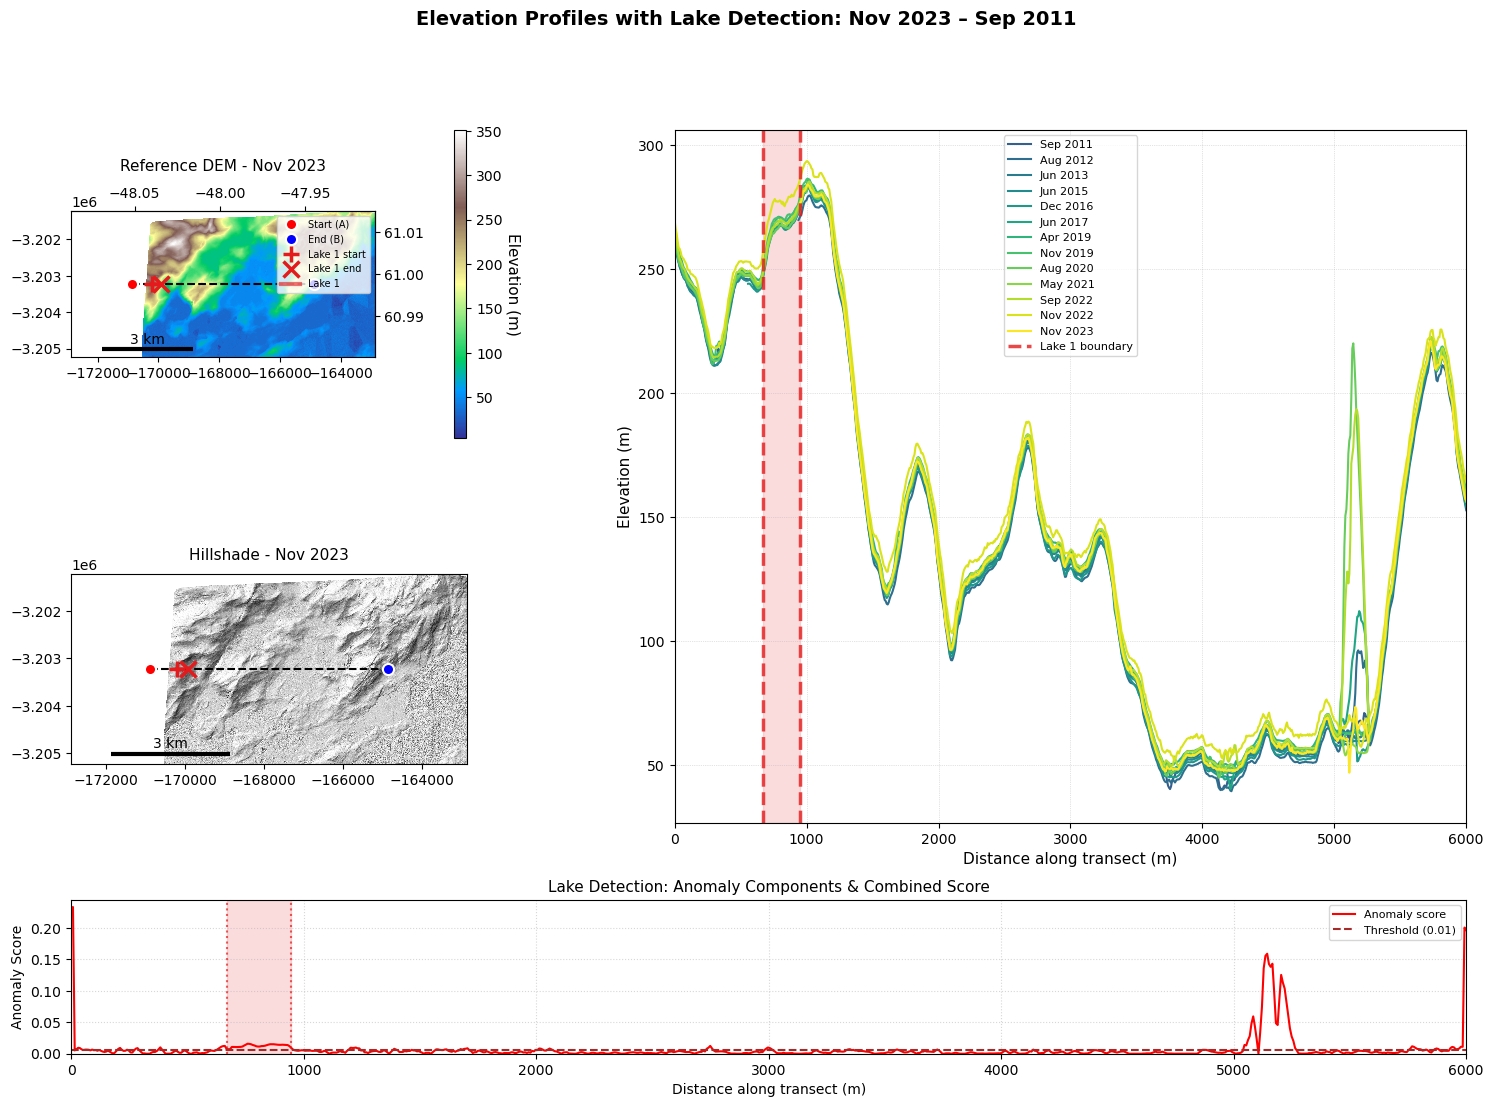

Lake detection plot saved to: /home/moralpom/luna/CPOM/moralpom/globe/data/ArcticDEM/transects_combined/profile_lakes_-48.054_60.999_-47.946_61.001-2011-2026_none.png

✓ Lake detection analysis complete!


In [9]:
# Cell 7: Subglacial Lake Detection
"""
## Subglacial Lake Detection
Identify potential subglacial lake boundaries based on localized elevation
changes in the profile data. Lakes appear as regions where the surface 
elevation changes rapidly compared to surrounding areas.
"""
import lake_detection  # Ensure lake_detection module is imported
importlib.reload(lake_detection)  # Reload the analysis module to ensure latest changes are used
# from analysis import detect_lake_boundaries, plot_lake_detection_results
from lake_detection import detect_lake_boundaries, plot_lake_detection_results

# Use the last transect that has profiles (filtered ones if available)
if 'all_transect_results' in locals():
    _with_profiles = [t.get('profiles_filtered', t['profiles']) for t in all_transect_results
                      if t.get('profiles_filtered', t['profiles'])['profiles']]
    if _with_profiles:
        all_profiles = _with_profiles[-1]
if not all_profiles.get('profiles'):
    raise ValueError("No transect has profiles to analyse")

print("Running lake detection algorithm...")
print("This looks for localized elevation changes that may indicate")
print("active subglacial lakes beneath the transect.\n")

# Run detection
lake_results = detect_lake_boundaries(
    all_profiles,  # Use filtered profiles
    min_depth=2.0,                   # Minimum 1.5m elevation change
    min_span_meters=200,             # At least 100m wide
    max_span_meters=5000,            # At most 5km wide
    min_profiles_showing=3,         # At least 1 profile must show anomaly
    smooth_window=3,                 # Smoothing for noise reduction
    prominence_threshold=0.5,      # Fraction of span to search for boundaries (15%)
    verbose=True
)

# Display results
if lake_results['lake_boundaries']:
    print(f"\n{'='*80}")
    print(f"DETECTED LAKE CANDIDATES: {len(lake_results['lake_boundaries'])}")
    print(f"{'='*80}")
    
    for i, lake in enumerate(lake_results['lake_boundaries']):
        print(f"\nLake Candidate {i+1}:")
        print(f"  Distance along transect: {lake['start_distance']:.0f} – {lake['end_distance']:.0f} m")
        print(f"  Span: {lake['span_meters']:.0f} m")
        print(f"  EPSG:3413 start: ({lake['start_coords_3413'][0]:.1f}, {lake['start_coords_3413'][1]:.1f})")
        print(f"  EPSG:3413 end:   ({lake['end_coords_3413'][0]:.1f}, {lake['end_coords_3413'][1]:.1f})")
        print(f"  WGS84 start: ({lake['start_coords_4326'][0]:.6f}°E, {lake['start_coords_4326'][1]:.6f}°N)")
        print(f"  WGS84 end:   ({lake['end_coords_4326'][0]:.6f}°E, {lake['end_coords_4326'][1]:.6f}°N)")
        print(f"  Confidence: {lake['confidence']:.2f}")
        print(f"  Profiles affected: {lake['n_profiles_affected']}")
else:
    print(f"\n{'='*80}")
    print(f"NO LAKE CANDIDATES DETECTED")
    print(f"{'='*80}")
    print("No regions with significant localized elevation changes found.")
    print("This transect may not intersect any active subglacial lakes,")
    print("or the signal may be below the detection threshold.")

# Generate lake detection plot
print("\nGenerating lake detection visualization...")
lake_plot_path = plot_lake_detection_results(
    all_profiles,
    lake_results,
    coreg_mode=COREG_MODE,
    lake_name=LAKE_NAME
)

print(f"\n✓ Lake detection analysis complete!")